# Supplemental ELI Diagnostics

This notebook contains the diagnostics split from `8_refactor_eli_skill_ts.ipynb`. It begins with the standalone NMME ELI lead-time benchmark, followed by the observational/model loading and lead-dependent drift diagnostic. It is self-contained and can be run from a fresh kernel.


In [63]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
import sys
import subprocess
import re
from pathlib import Path

# Resolve native-library paths from the active kernel.
_env_prefix = sys.prefix
_proj_path  = os.path.join(_env_prefix, "share", "proj")
if os.path.isfile(os.path.join(_proj_path, "proj.db")):
    os.environ["CONDA_PREFIX"] = _env_prefix
    os.environ["PROJ_LIB"]    = _proj_path
    os.environ["PROJ_DATA"]   = _proj_path
else:
    print("PROJ_LIB not set, proj.db not found.")

import dask
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from IPython.display import display

from esp_lab import eli_diagnostics as eli_tools
from esp_lab.utils import mov_utils as mov
from esp_lab.utils.dask_util import DaskConfig, get_cluster_client
from esp_lab.utils.notebook_resources import restart_notebook_cluster, close_notebook_resources

REPO_ROOT = Path(eli_tools.__file__).resolve().parents[1]
NATIVE_ELI_SCRIPT = REPO_ROOT / "scripts" / "run_process_native_eli.py"
if not NATIVE_ELI_SCRIPT.is_file():
    raise FileNotFoundError(f"Native ELI processor not found: {NATIVE_ELI_SCRIPT}")

print(f"Python      : {sys.executable}")
print(f"CONDA_PREFIX: {os.environ.get('CONDA_PREFIX', '(not set)')}")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Python      : /global/homes/z/zhan391/.conda/envs/e3sm_analysis/bin/python
CONDA_PREFIX: /global/homes/z/zhan391/.conda/envs/e3sm_analysis


## Managed Dask resources

Create one managed cluster for lazy cache reads and computations. Re-running this cell first closes resources from the previous run, following the `1a_refactor*` lifecycle.


In [64]:
from dask.distributed import wait

# Explicit per-notebook limits; DaskConfig also caps local shared nodes at four workers.
DASK_SETTINGS = {
    "enabled": True,
    "cluster_type": os.environ.get("CLUSTER_TYPE", "local"),
    "workers": 4,
    "cores": 1,
    "memory_limit": "4GB",
}
dask_cfg = DaskConfig(
    cluster_type=DASK_SETTINGS["cluster_type"],
    workers=DASK_SETTINGS["workers"],
    cores=DASK_SETTINGS["cores"],
    memory_limit=DASK_SETTINGS["memory_limit"],
    walltime="02:00:00",
)
cluster, client, workflow_resources = restart_notebook_cluster(
    globals(),
    lambda: get_cluster_client(dask_cfg) if DASK_SETTINGS["enabled"] else (None, None),
)

def open_tracked_dataset(path, *, chunks="auto"):
    """Open a lazy dataset owned by this notebook's resource tracker."""
    return workflow_resources.track(xr.open_dataset(path, chunks=chunks))

print(client)
print("xarray:", xr.__version__)
print("dask:", dask.__version__)



!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
This can easily exceed memory/CPU limits and crash your Jupyter kernel.
We highly recommend launching Jupyter on an Exclusive Perlmutter Compute Node.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 33337 instead
  warnings.warn(


Scheduler: tcp://127.0.0.1:39567
Connected workers: 4
Dashboard: http://127.0.0.1:33337/status
<Client: 'tcp://127.0.0.1:39567' processes=4 threads=4, memory=14.90 GiB>
xarray: 2026.4.0
dask: 2026.3.0


## Configuration

The paths, model registry, evaluation period, and figure naming match `8_refactor_eli_skill_ts.ipynb`.


In [65]:
# Optional common processing end year. None uses 2018.
YEAR_END = 2011  # None
START_YEAR = 1980
END_YEAR = 2018 if YEAR_END is None else int(YEAR_END)
INIT_MONTHS = [5, 11]
CLIM_Y0, CLIM_Y1 = 1981, 2010
NLEAD = 24
ELI_INPUT_GRID = "native"
ELI_CHUNKS = {"Y": -1, "L": 1, "M": -1}
ELI_CACHE_MODE = "auto"  # auto | require
ELI_CACHE_WORKERS = 4
FONTZ = 16

# -----------------------------------------------------------------------------
# Shared paths and run control
# -----------------------------------------------------------------------------
S2D_DIAG_ROOT = Path("/global/cfs/cdirs/e3sm/S2S2D/s2d_diag")
E3SMLE_DIAG_DIR = S2D_DIAG_ROOT
CESM_SMYLE_DIAG_DIR = S2D_DIAG_ROOT / "CESM-SMYLE"
NMME_DIAG_DIR = S2D_DIAG_ROOT / "NMME"
HADISST2_DIAG_DIR = S2D_DIAG_ROOT / "HadISST2"
MODES_VARIABILITY_DIAG_DIR = S2D_DIAG_ROOT

DIAG_ROOT = S2D_DIAG_ROOT
E3SMLE_OUTDIR = E3SMLE_DIAG_DIR
CESM_SMYLE_OUTDIR = CESM_SMYLE_DIAG_DIR
NMME_OUTDIR = NMME_DIAG_DIR
NMME_PERIOD_TAG = "1980_2020"
NMME_ELI_TIMESERIES_DIR = NMME_OUTDIR / "sst_index" / "timeseries"
NMME_ELI_TIMESERIES_FILES = {
    month: NMME_ELI_TIMESERIES_DIR / f"NMME{month:02d}_ELI_mon_dd_{NMME_PERIOD_TAG}.nc"
    for month in [2, 5, 8, 11]
}
NMME_ELI_OBS_FILE = HADISST2_DIAG_DIR / "sst_index" / "timeseries" / "HadISST2_sst_ELI_mon.nc"

OBS_ELI_FILE = Path(
    "/global/cfs/cdirs/e3sm/lvroekel/ELI_ERSSTv5_1854.01-2020.05.xlsx"
)
NINO34_OBS_FILE = HADISST2_DIAG_DIR / "sst_index" / "timeseries" / "HadISST2_sst_Nino3.4SST_mon.nc"
FIGURE_OUTDIR = Path("/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag")
FIGURE_OUTDIR.mkdir(parents=True, exist_ok=True)

MODEL_SPECS = {
    "CESM-SMYLE": eli_tools.ELIModelSpec(
        key="CESM-SMYLE",
        label="CESM-SMYLE",
        root=CESM_SMYLE_OUTDIR / "sst_index" / "timeseries",
        filename_template="BSMYLE{init_month:02d}_ELI_N{nens:02d}_M{nlead:02d}.nc",
        ensemble_size=20,
        color="tab:orange",
        marker="s",
    ),
    "E3SM-FOSIRL": eli_tools.ELIModelSpec(
        key="E3SM-FOSIRL",
        label="E3SMv3-FOSIRL",
        root=E3SMLE_OUTDIR / "JRA55_FOSIRL" / "sst_index" / "timeseries",
        filename_template=(
            "E3SMLE{init_month:02d}_ELI_native_N{nens:02d}_M{nlead:02d}.nc"
            if ELI_INPUT_GRID == "native"
            else "E3SMLE{init_month:02d}_ELI_N{nens:02d}_M{nlead:02d}.nc"
        ),
        ensemble_size=10,
        color="black",
        marker="o",
    ),
    "E3SM-Reanalysis": eli_tools.ELIModelSpec(
        key="E3SM-Reanalysis",
        label="E3SMv3-Reanalysis",
        root=E3SMLE_OUTDIR / "Reanalysis" / "sst_index" / "timeseries",
        filename_template=(
            "E3SMLE{init_month:02d}_ELI_native_N{nens:02d}_M{nlead:02d}.nc"
            if ELI_INPUT_GRID == "native"
            else "E3SMLE{init_month:02d}_ELI_N{nens:02d}_M{nlead:02d}.nc"
        ),
        ensemble_size=10,
        color="tab:blue",
        marker="^",
    ),
    "E3SM-4DEnVarOcn": eli_tools.ELIModelSpec(
        key="E3SM-4DEnVarOcn",
        label="E3SMv3-4DEnVarOcn",
        root=E3SMLE_OUTDIR / "4DEnVarOcn" / "sst_index" / "timeseries",
        filename_template=(
            "E3SMLE{init_month:02d}_ELI_native_N{nens:02d}_M{nlead:02d}.nc"
            if ELI_INPUT_GRID == "native"
            else "E3SMLE{init_month:02d}_ELI_N{nens:02d}_M{nlead:02d}.nc"
        ),
        ensemble_size=10,
        color="tab:purple",
        marker="D",
    ),
}
E3SM_NATIVE_CASES = {
    "E3SM-FOSIRL": "JRA55_FOSIRL",
    "E3SM-Reanalysis": "Reanalysis",
    "E3SM-4DEnVarOcn": "4DEnVarOcn",
}
if ELI_CACHE_MODE not in {"auto", "require"}:
    raise ValueError("ELI_CACHE_MODE must be 'auto' or 'require'")

NMME_BENCHMARK_PLOT_CONFIG = {
    "filename_parts": ("eli", "nmme", "lead_time_benchmark"),
    "figfmt": "png",
    "dpi": 300,
    "figsize": (14, 18),
    "font_size": FONTZ,
    "figure_title": "NMME ELI Monthly Lead-time Skill (All Available Models, 1980–2020)",
    "figure_title_font_scale": 1.1,
    "figure_title_y": 0.995,
    "panel_title_font_scale": 1.00,
    "axis_label_font_scale": 0.95,
    "tick_font_scale": 0.90,
    "legend_font_scale": 0.90,
    "line_width": 2.0,
    "benchmark_line_width": 3.2,
    "marker_size": 6,
    "benchmark_marker_size": 8,
    "startmonths": [2, 5, 8, 11],
    "startmonth_labels": {2: "FEB init", 5: "MAY init", 8: "AUG init", 11: "NOV init"},
    "startmonth_colors": {2: "tab:blue", 5: "tab:orange", 8: "tab:green", 11: "tab:purple"},
    "startmonth_markers": {2: "o", 5: "o", 8: "o", 11: "o"},
    "init_line_label": "NMME multi-model mean",
    "benchmark_label": "NMME all-init mean",
    "benchmark_color": "tab:red",
    "benchmark_marker": "o",
    "spread_label": "Model-weight range",
    "spread_alpha": 0.16,
    "spread_quantiles": (0.0, 1.0),
    "evaluation_years": (1980, 2020),
    "minimum_models_per_year": 2,
    "minimum_valid_years": 20,
    "bootstrap_iterations": 1000,
    "bootstrap_random_seed": 391,
    "detrend": True,
    "show_model_counts": True,
    "model_count_font_scale": 0.70,
    "model_count_axis_label": "Forecast lead (months, median models/year)",
    "acc_ylim": [0.1, 1.0],
    "nrmse_ylim": [0.2, 1.1],
    "acc_label": "ACC",
    "nrmse_label": "nRMSE",
    "lead_axis_label": "Forecast lead (months)",
    "lead_axis_margin": 0.35,
    "xlabels_on_all_rows": False,
    "grid_alpha": 0.35,
    "acc_reference": 0.5,
    "nrmse_reference": 1.0,
    "reference_color": "0.25",
    "reference_linestyle": "--",
    "reference_line_width": 1.2,
    "lead_offset": 1,
    "all_init_row_label": "All-init mean",
    "legend_loc": "lower center",
    "legend_bbox": (0.5, 0.015),
    "legend_ncol": 6,
    "legend_spread_color": "0.55",
    "layout_rect": [0, 0.065, 1, 0.94],
    "layout_h_pad": 1.8,
    "layout_w_pad": 1.2,
    "metric": "eli_nmme_lead_time_benchmark",
    "title": "NMME ELI Lead-time Benchmark",
    "caption": (
        "Monthly NMME ELI skill for 1980–2020 against HadISST2. "
        "Dot lines show ACC and nRMSE from the equal-weight mean of all "
        "models available in each verification year; colored rows are "
        "initialization-specific and the red row is their mean. Shading "
        "shows the minimum–maximum skill across 1,000 Bayesian model-weight "
        "samples. N is the median number of contributing models per year; "
        "the companion table reports its minimum and maximum."
    ),
}

ELI_NINO34_PLOT_CONFIG = {
    "filename_parts": ("observed_model", "eli", "nino34", "dual_axis"),
    "figfmt": "png",
    "dpi": 300,
    "figsize": (24, 15.5),
    "font_size": FONTZ,
    "figure_title_template": "Observed and Model ELI versus Niño3.4 ({verification_period} means)",
    "figure_title_font_scale": 1.15,
    "figure_title_y": 0.985,
    "column_header_font_scale": 1.05,
    "column_header_y": 1.10,
    "panel_title_font_scale": 0.95,
    "axis_label_font_scale": 0.9,
    "tick_font_scale": 0.85,
    "legend_font_scale": 0.80,
    "line_width": 2.5,
    "ensemble_spread_percentiles": (0, 100),
    "ensemble_spread_alpha": 0.22,
    "verification_period": "DJF",
    "center_month": 1,
    "season_window": 3,
    "lead_columns": [
        {"init_month": 11, "lead": 1, "center_lead": 3, "label": "NOV init → DJF (1-month lead)"},
        {"init_month": 11, "lead": 13, "center_lead": 15, "label": "NOV init → DJF (13-month lead)"},
        {"init_month": 5, "lead": 7, "center_lead": 9, "label": "MAY init → DJF (7-month lead)"},
        {"init_month": 5, "lead": 19, "center_lead": 21, "label": "MAY init → DJF (19-month lead)"},
    ],
    "eli_label": "ELI",
    "eli_axis_label": "ELI longitude (°E)",
    "eli_color": "tab:red",
    "eli_ylim": [140, 200],
    "eli_yticks": np.arange(140, 201, 10),
    "nino34_label": "Niño3.4",
    "nino34_axis_label": "Niño3.4 anomaly (°C)",
    "nino34_color": "black",
    "nino34_ylim": [-4, 4],
    "nino34_yticks": np.arange(-4, 4.1, 1),
    "zero_line_color": "0.25",
    "zero_line_width": 1.0,
    "grid_alpha": 0.30,
    "legend_loc": "lower center",
    "legend_bbox": (0.5, 0.015),
    "legend_frame_alpha": 0.95,
    "legend_facecolor": "#fcfcfc",
    "legend_edgecolor": "#d0d0d0",
    "panel_hspace": 0.32,
    "panel_wspace": 0.12,
    "legend_ncol": 3,
    "target_year_label": "Year",
    "layout_rect": [0.035, 0.065, 0.965, 0.94],
    "layout_h_pad": 1.4,
    "layout_w_pad": 0.8,
    "metric": "observed_model_eli_nino34_dual_axis",
    "title": "Observed and Model ELI–Niño3.4 Comparison",
    "caption_template": (
        "Observed and ensemble-mean model ELI longitude versus Niño3.4 "
        "{verification_period}-mean SST anomaly. Each {verification_period} point is a centered "
        "three-month mean. "
        "The observational row uses "
        "ERSSTv5 ELI and HadISST2 Niño3.4; each model row uses the "
        "corresponding forecast system's ensemble means. Light red and black "
        "shading shows the ensemble minimum–maximum range in model panels; the "
        "observational panels are unshaded. ELI is shown directly in "
        "degrees east; Niño3.4 subtracts its 1981–2010 calendar-month or "
        "model initialization- and lead-specific climatology. Columns "
        "compare {column_description}. "
        "Each column uses one common target-year cohort across observations "
        "and all models. Observational titles report one ELI–Niño3.4 "
        "correlation; model titles report the mean ± standard deviation of "
        "member-wise correlations."
    ),
}

ELI_NINO34_JJA_PLOT_CONFIG = {
    **ELI_NINO34_PLOT_CONFIG,
    "verification_period": "JJA",
    "center_month": 7,
    "lead_columns": [
        {"init_month": 5, "lead": 1, "center_lead": 3, "label": "MAY init → JJA (1-month lead)"},
        {"init_month": 5, "lead": 13, "center_lead": 15, "label": "MAY init → JJA (13-month lead)"},
        {"init_month": 11, "lead": 7, "center_lead": 9, "label": "NOV init → JJA (7-month lead)"},
        {"init_month": 11, "lead": 19, "center_lead": 21, "label": "NOV init → JJA (19-month lead)"},
    ],
}
ELI_NINO34_PLOT_CONFIGS = [ELI_NINO34_PLOT_CONFIG, ELI_NINO34_JJA_PLOT_CONFIG]

DRIFT_CLIMATOLOGY_PLOT_CONFIG = {
    "figsize": (16, 10),
    "dpi": 300,
    "font_size": FONTZ,
    "figure_title": "Lead-dependent ELI and Niño3.4 Climatology (1981–2010)",
    "figure_title_font_scale": 1.30,
    "figure_title_y": 0.965,
    "panel_title_font_scale": 1.05,
    "axis_label_font_scale": 1.00,
    "tick_font_scale": 0.90,
    "legend_font_scale": 0.85,
    "obs_line_width": 2.8,
    "eli_obs_color": "tab:green",
    "eli_obs_linestyle": "--",
    "nino34_obs_color": "tab:red",
    "nino34_obs_linestyle": ":",
    "model_line_width": 2.4,
    "ensemble_spread_percentiles": (0, 100),
    "ensemble_spread_alpha": 0.20,
    "grid_alpha": 0.30,
    "lead_tick_interval": 3,
    "init_labels": {5: "May Initialization", 11: "November Initialization"},
    "eli_obs_label": "ERSSTv5 (ELI)",
    "nino34_obs_label": "HadISST2 (Niño3.4)",
    "eli_ylabel": "ELI Climatology (°E)",
    "nino34_ylabel": "Niño3.4 SST Climatology (°C)",
    "xlabel": "Forecast Lead (months)",
    "subplot_adjust": {"top": 0.85, "bottom": 0.19, "left": 0.08, "right": 0.96, "hspace": 0.25, "wspace": 0.08},
    "legend_bbox": (0.50, 0.012),
    "legend_ncol": 4,
    "filename_parts": ("eli", "nino34", "multimodel", "drift_climatology"),
    "metric": "eli_nino34_multimodel_drift",
}

def figure_filename(*parts, ext="png"):
    """Return the shared, filesystem-safe figure filename."""
    clean = ["fig"]
    for part in parts:
        token = re.sub(r"[^A-Za-z0-9]+", "_", str(part).strip()).strip("_").lower()
        if token:
            clean.append(token)
    return "_".join(clean) + f".{ext.lstrip('.')}"

print(f"Evaluation years: {START_YEAR}-{END_YEAR}")
print(f"Climatology: {CLIM_Y0}-{CLIM_Y1}")
print(f"Initialization months: {INIT_MONTHS}")
print(f"ELI input grid: {ELI_INPUT_GRID}")
print("Models:", [spec.label for spec in MODEL_SPECS.values()])


Evaluation years: 1980-2011
Climatology: 1981-2010
Initialization months: [5, 11]
ELI input grid: native
Models: ['CESM-SMYLE', 'E3SMv3-FOSIRL', 'E3SMv3-Reanalysis', 'E3SMv3-4DEnVarOcn']


In [66]:
def nino34_model_path(model, init_month):
    """Return the monthly model Niño3.4 cache matching an ELI cache."""
    spec = MODEL_SPECS[model]
    prefix = "BSMYLE" if model == "CESM-SMYLE" else "E3SMLE"
    filename = (
        f"{prefix}{int(init_month):02d}_TS_N{spec.ensemble_size:02d}_"
        f"M{NLEAD:02d}_Nino3.4SST_mon.nc"
    )
    return spec.root / filename

def _detrend_values(values, years, config):
    values = np.asarray(values, dtype=float)
    if not config["detrend"]:
        return values
    years = np.asarray(years, dtype=float)
    centered_years = years - years.mean()
    slope, intercept = np.polyfit(centered_years, values, 1)
    return values - (slope * centered_years + intercept)

def _skill_pair(forecast, observed, years, config):
    valid = np.isfinite(forecast) & np.isfinite(observed)
    if valid.sum() < config["minimum_valid_years"]:
        return np.nan, np.nan
    forecast_valid = _detrend_values(forecast[valid], years[valid], config)
    observed_valid = _detrend_values(observed[valid], years[valid], config)
    obs_std = np.std(observed_valid)
    if obs_std == 0:
        return np.nan, np.nan
    acc = np.corrcoef(forecast_valid, observed_valid)[0, 1]
    nrmse = np.sqrt(np.mean((forecast_valid - observed_valid) ** 2)) / obs_std
    return float(acc), float(nrmse)

def _compute_all_available_skill(init_month, config, obs_lookup, rng):
    source = open_tracked_dataset(NMME_ELI_TIMESERIES_FILES[init_month])
    year0, year1 = config["evaluation_years"]
    source = source.sel(Y=slice(year0, year1))
    model_forecast = source["sst"].mean("M", skipna=True)
    leads = np.asarray(source.L.values, dtype=int)
    n_bootstrap = config["bootstrap_iterations"]
    acc = np.full(leads.size, np.nan)
    nrmse = np.full(leads.size, np.nan)
    acc_bootstrap = np.full((n_bootstrap, leads.size), np.nan)
    nrmse_bootstrap = np.full((n_bootstrap, leads.size), np.nan)
    count_min = np.full(leads.size, np.nan)
    count_median = np.full(leads.size, np.nan)
    count_max = np.full(leads.size, np.nan)
    valid_year_count = np.zeros(leads.size, dtype=int)

    for lead_index, lead in enumerate(leads):
        forecast = np.asarray(
            model_forecast.sel(L=lead).transpose("model", "Y").values,
            dtype=float,
        )
        target_time = source["time"].sel(L=lead)
        target_year = np.asarray(target_time.dt.year.values, dtype=int)
        target_month = np.asarray(target_time.dt.month.values, dtype=int)
        observed = np.asarray([
            obs_lookup.get((int(year), int(month)), np.nan)
            for year, month in zip(target_year, target_month)
        ])
        finite = np.isfinite(forecast)
        model_count = finite.sum(axis=0)
        denominator = model_count.astype(float)
        ensemble_mean = np.divide(
            np.nansum(forecast, axis=0), denominator,
            out=np.full(target_year.size, np.nan), where=denominator > 0,
        )
        valid = (
            (model_count >= config["minimum_models_per_year"])
            & np.isfinite(observed)
        )
        acc[lead_index], nrmse[lead_index] = _skill_pair(
            ensemble_mean[valid], observed[valid], target_year[valid], config
        )
        valid_counts = model_count[valid]
        valid_year_count[lead_index] = valid.sum()
        if valid_counts.size:
            count_min[lead_index] = valid_counts.min()
            count_median[lead_index] = np.median(valid_counts)
            count_max[lead_index] = valid_counts.max()

        for bootstrap_index in range(n_bootstrap):
            weights = rng.dirichlet(np.ones(forecast.shape[0]))[:, None]
            weighted_denominator = np.sum(weights * finite, axis=0)
            weighted_mean = np.divide(
                np.nansum(weights * forecast, axis=0), weighted_denominator,
                out=np.full(target_year.size, np.nan),
                where=weighted_denominator > 0,
            )
            (
                acc_bootstrap[bootstrap_index, lead_index],
                nrmse_bootstrap[bootstrap_index, lead_index],
            ) = _skill_pair(
                weighted_mean[valid], observed[valid], target_year[valid], config
            )

    return xr.Dataset(
        {
            "acc": ("lead", acc),
            "nrmse": ("lead", nrmse),
            "acc_bootstrap": (("bootstrap", "lead"), acc_bootstrap),
            "nrmse_bootstrap": (("bootstrap", "lead"), nrmse_bootstrap),
            "model_count_min": ("lead", count_min),
            "model_count_median": ("lead", count_median),
            "model_count_max": ("lead", count_max),
            "valid_year_count": ("lead", valid_year_count),
        },
        coords={"lead": leads, "bootstrap": np.arange(n_bootstrap)},
    )


## Validate required inputs


In [67]:
if not OBS_ELI_FILE.is_file():
    raise FileNotFoundError(f"Observational ELI file not found: {OBS_ELI_FILE}")
if not NINO34_OBS_FILE.is_file():
    raise FileNotFoundError(f"Observational Niño3.4 file not found: {NINO34_OBS_FILE}")

required_model_files = {
    model: [spec.path(month, NLEAD) for month in INIT_MONTHS]
    for model, spec in MODEL_SPECS.items()
}
missing_eli_by_model = {
    model: [path for path in paths if not path.is_file()]
    for model, paths in required_model_files.items()
}
missing_eli_by_model = {
    model: paths for model, paths in missing_eli_by_model.items() if paths
}
missing_e3sm_cases = [
    E3SM_NATIVE_CASES[model]
    for model in missing_eli_by_model
    if model in E3SM_NATIVE_CASES
]
if missing_e3sm_cases and ELI_CACHE_MODE == "auto" and ELI_INPUT_GRID == "native":
    command = [
        sys.executable, str(NATIVE_ELI_SCRIPT),
        "--cases", *missing_e3sm_cases,
        "--outdir", str(DIAG_ROOT),
        "--init-months", *map(str, INIT_MONTHS),
        "--year-start", str(START_YEAR),
        "--year-end", str(END_YEAR),
        "--nlead", str(NLEAD),
        "--e3sm-nens", "10",
        "--workers", str(ELI_CACHE_WORKERS),
    ]
    print("Preparing missing native ELI caches for:", missing_e3sm_cases)
    subprocess.run(command, check=True)

missing_eli_files = [
    path for paths in required_model_files.values() for path in paths
    if not path.is_file()
]
required_nino34_model_files = {
    model: [nino34_model_path(model, month) for month in INIT_MONTHS]
    for model in MODEL_SPECS
}
missing_nino34_model_files = [
    path
    for paths in required_nino34_model_files.values()
    for path in paths
    if not path.is_file()
]
missing_required_files = missing_eli_files + missing_nino34_model_files
if missing_required_files:
    raise FileNotFoundError(
        f"Missing required diagnostic caches after ELI_CACHE_MODE={ELI_CACHE_MODE!r}:\n"
        + "\n".join(f"  {path}" for path in missing_required_files)
    )

missing_nmme_benchmark_files = [
    path for path in [*NMME_ELI_TIMESERIES_FILES.values(), NMME_ELI_OBS_FILE]
    if not path.is_file()
]
NMME_ELI_BENCHMARK_AVAILABLE = not missing_nmme_benchmark_files
if missing_nmme_benchmark_files:
    print("NMME benchmark will be skipped; missing optional inputs:")
    print("\n".join(f"  {path}" for path in missing_nmme_benchmark_files))
print("Configuration valid")
for model, paths in required_model_files.items():
    print(f"  {MODEL_SPECS[model].label}:")
    for path in paths:
        print(f"    {path.name}")
    for path in required_nino34_model_files[model]:
        print(f"    {path.name}")
print(f"  NMME all-available benchmark inputs: {NMME_ELI_BENCHMARK_AVAILABLE}")


Configuration valid
  CESM-SMYLE:
    BSMYLE05_ELI_N20_M24.nc
    BSMYLE11_ELI_N20_M24.nc
    BSMYLE05_TS_N20_M24_Nino3.4SST_mon.nc
    BSMYLE11_TS_N20_M24_Nino3.4SST_mon.nc
  E3SMv3-FOSIRL:
    E3SMLE05_ELI_native_N10_M24.nc
    E3SMLE11_ELI_native_N10_M24.nc
    E3SMLE05_TS_N10_M24_Nino3.4SST_mon.nc
    E3SMLE11_TS_N10_M24_Nino3.4SST_mon.nc
  E3SMv3-Reanalysis:
    E3SMLE05_ELI_native_N10_M24.nc
    E3SMLE11_ELI_native_N10_M24.nc
    E3SMLE05_TS_N10_M24_Nino3.4SST_mon.nc
    E3SMLE11_TS_N10_M24_Nino3.4SST_mon.nc
  E3SMv3-4DEnVarOcn:
    E3SMLE05_ELI_native_N10_M24.nc
    E3SMLE11_ELI_native_N10_M24.nc
    E3SMLE05_TS_N10_M24_Nino3.4SST_mon.nc
    E3SMLE11_TS_N10_M24_Nino3.4SST_mon.nc
  NMME all-available benchmark inputs: True


## 1. NMME ELI lead-time benchmark

Use all available NMME ELI model time series as a compact monthly predictability reference. Initialization-specific multi-model means show seasonality, the bold all-initialization mean provides the benchmark, Bayesian model-bootstrap minimum–maximum ranges show the most adverse and favorable sampled model compositions, and the lead labels report the changing number of contributing models.


NMME model availability by initialization and lead


models_median  models_min  models_max  verification_years
initialization lead                                                           
FEB init       0                12           2          12                  41
               1                12           2          12                  41
               2                12           2          12                  41
               3                12           2          12                  41
               4                12           2          12                  41
               5                12           2          12                  41
               6                12           2          12                  41
               7                12           2          12                  41
               8                12           2          12                  41
               9                 9           2           9                  41
               10                9           2           9                  41
               11                9           2           9                  41
MAY init       0                12           3          12                  41
               1                12           3          12                  41
               2                12           3          12                  41
               3                12           3          12                  41
               4                12           3          12                  41
               5                12           3          12                  41
               6                12           3          12                  41
               7                12           3          12                  41
               8                12           3          12                  41
               9                 9           3           9                  41
               10                9           3           9                  41
               11                9           3           9                  41
AUG init       0                12           3          12                  41
               1                12           3          12                  41
               2                12           3          12                  41
               3                12           3          12                  41
               4                12           3          12                  41
               5                12           3          12                  41
               6                12           3          12                  41
               7                12           3          12                  41
               8                12           3          12                  41
               9                 9           3           9                  41
               10                9           3           9                  41
               11                9           3           9                  41
NOV init       0                12           3          12                  41
               1                12           3          12                  41
               2                12           3          12                  41
               3                12           3          12                  41
               4                12           3          12                  41
               5                12           3          12                  41
               6                12           3          12                  41
               7                12           3          12                  41
               8                12           3          12                  41
               9                 9           3           9                  41
               10                9           3           9                  41
               11                9           3           9                  41

Saved figure: /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_eli_nmme_lead_time_benchmark.png


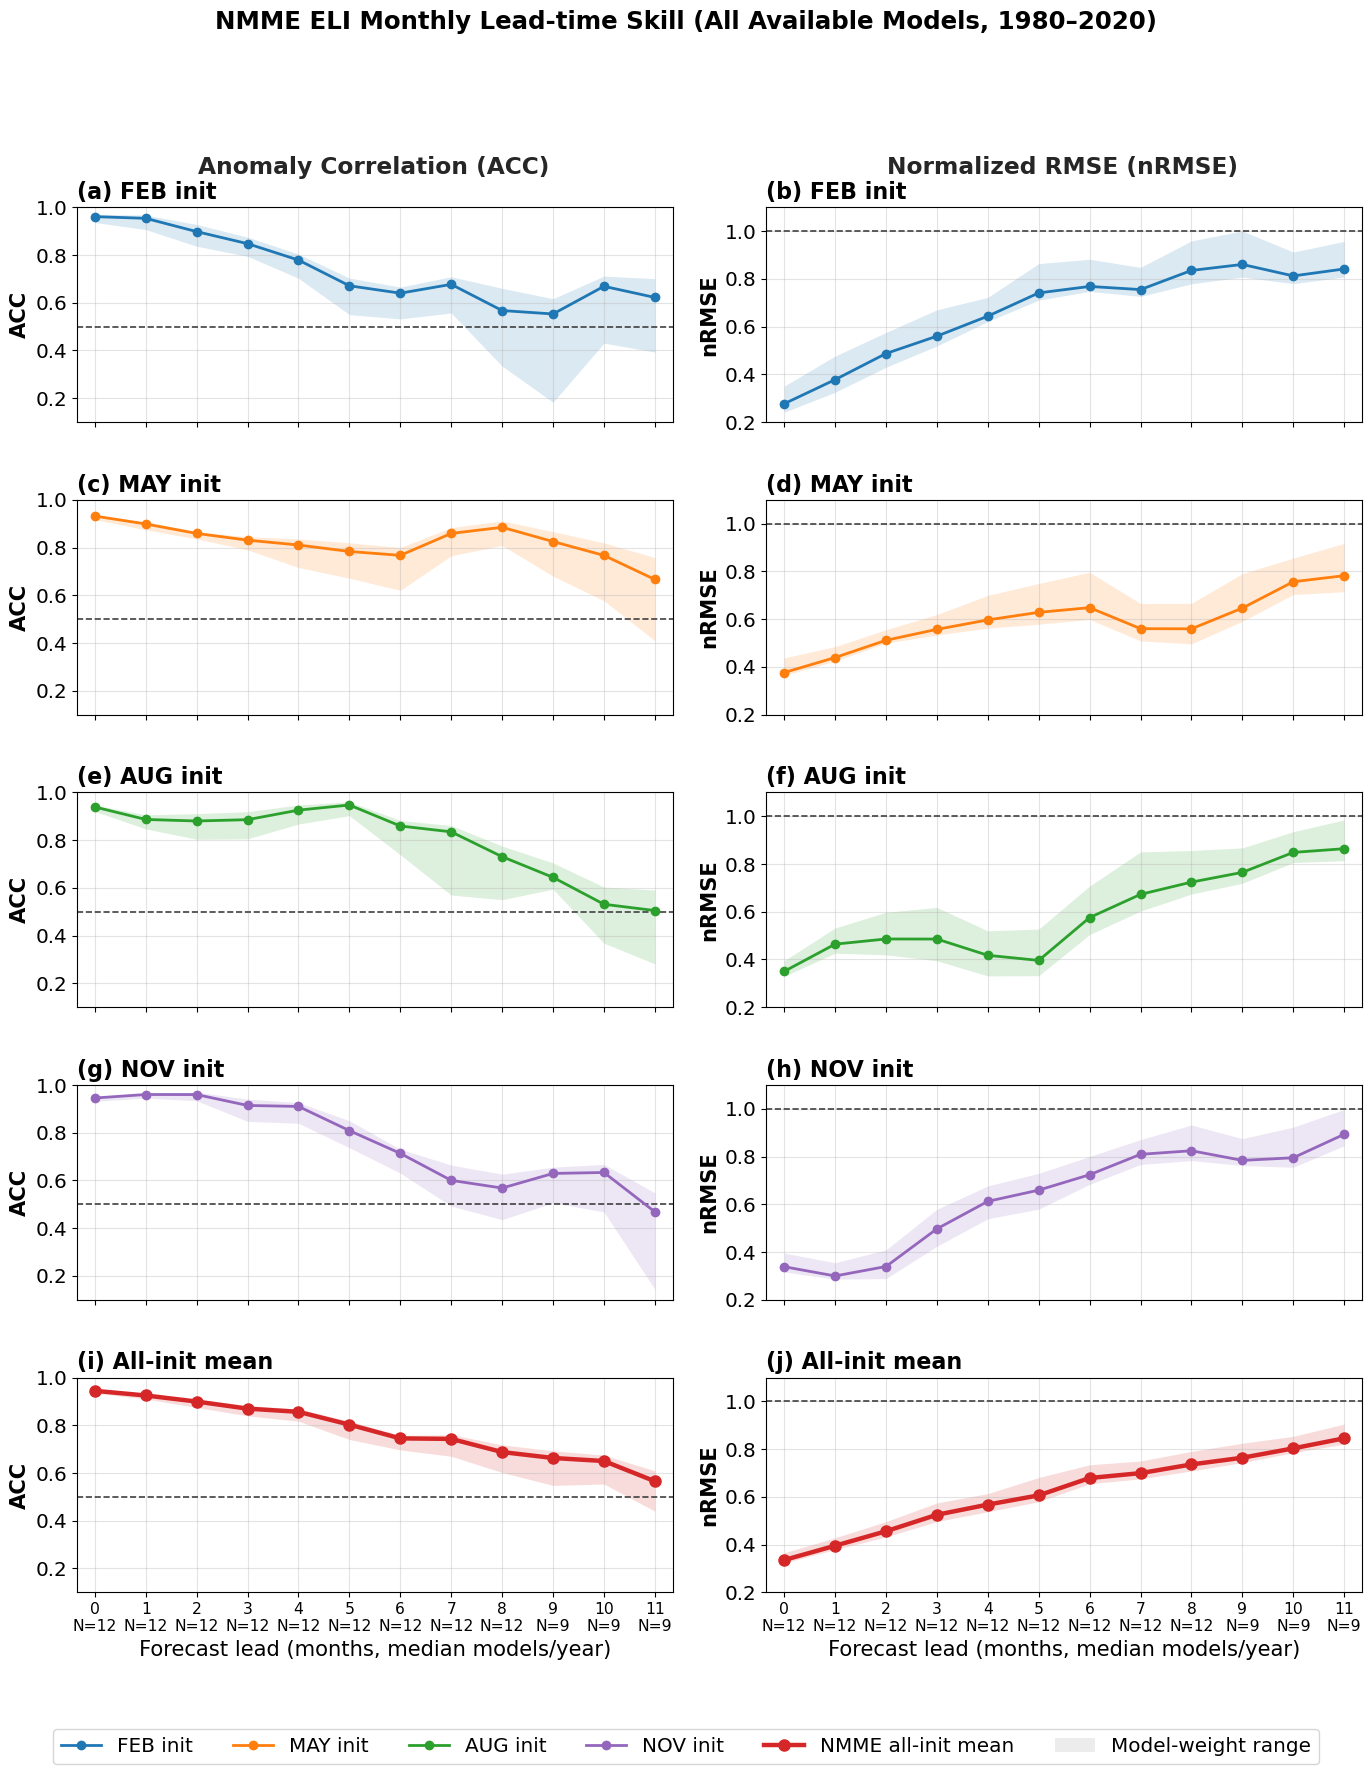

In [68]:
# -----------------------------
# Plot the NMME ELI lead-time benchmark
# -----------------------------
if not NMME_ELI_BENCHMARK_AVAILABLE:
    print("Skipping NMME ELI benchmark because required inputs are missing.")
else:
    plot_cfg = NMME_BENCHMARK_PLOT_CONFIG
    startmonths = list(plot_cfg["startmonths"])

    fontz = plot_cfg["font_size"]
    panel_title_fontz = fontz * plot_cfg["panel_title_font_scale"]
    axis_label_fontz = fontz * plot_cfg["axis_label_font_scale"]
    tick_fontz = fontz * plot_cfg["tick_font_scale"]
    legend_fontz = fontz * plot_cfg["legend_font_scale"]
    model_count_fontz = fontz * plot_cfg["model_count_font_scale"]
    plt.rcParams.update({
        "font.size": fontz,
        "axes.titlesize": panel_title_fontz,
        "axes.labelsize": axis_label_fontz,
        "xtick.labelsize": tick_fontz,
        "ytick.labelsize": tick_fontz,
        "legend.fontsize": legend_fontz,
    })

    obs_ds = open_tracked_dataset(NMME_ELI_OBS_FILE)
    obs_eli = obs_ds["eli"]
    obs_year = np.asarray(obs_eli.time.dt.year.values, dtype=int)
    obs_month = np.asarray(obs_eli.time.dt.month.values, dtype=int)
    obs_value = np.asarray(obs_eli.values, dtype=float)
    obs_lookup = {}
    for calendar_month in range(1, 13):
        clim_mask = (
            (obs_month == calendar_month)
            & (obs_year >= CLIM_Y0)
            & (obs_year <= CLIM_Y1)
        )
        clim_mean = np.nanmean(obs_value[clim_mask])
        month_mask = obs_month == calendar_month
        for year, value in zip(obs_year[month_mask], obs_value[month_mask]):
            obs_lookup[(int(year), calendar_month)] = float(value - clim_mean)

    rng = np.random.default_rng(plot_cfg["bootstrap_random_seed"])
    
    skill_by_init = {
        month: _compute_all_available_skill(month, plot_cfg, obs_lookup, rng)
        for month in startmonths
    }
    x = skill_by_init[startmonths[0]].lead.values - plot_cfg["lead_offset"]

    row_specs = [
        {
            "label": plot_cfg["startmonth_labels"][month],
            "color": plot_cfg["startmonth_colors"][month],
            "marker": plot_cfg["startmonth_markers"][month],
            "line_label": plot_cfg["init_line_label"],
            "acc": skill_by_init[month]["acc"],
            "nrmse": skill_by_init[month]["nrmse"],
            "spread_acc": skill_by_init[month]["acc_bootstrap"],
            "spread_nrmse": skill_by_init[month]["nrmse_bootstrap"],
            "count_min": skill_by_init[month]["model_count_min"],
            "count_median": skill_by_init[month]["model_count_median"],
            "count_max": skill_by_init[month]["model_count_max"],
            "is_all_init": False,
        }
        for month in startmonths
    ]
    init_skill = xr.concat(
        [skill_by_init[month] for month in startmonths],
        dim=xr.DataArray(startmonths, dims="startmonth", name="startmonth"),
    )
    availability_rows = []
    for month in startmonths:
        monthly_skill = skill_by_init[month]
        for lead_index, lead in enumerate(x):
            availability_rows.append({
                "initialization": plot_cfg["startmonth_labels"][month],
                "lead": int(lead),
                "models_median": int(monthly_skill["model_count_median"].values[lead_index]),
                "models_min": int(monthly_skill["model_count_min"].values[lead_index]),
                "models_max": int(monthly_skill["model_count_max"].values[lead_index]),
                "verification_years": int(monthly_skill["valid_year_count"].values[lead_index]),
            })
    availability_table = pd.DataFrame(availability_rows)
    print("NMME model availability by initialization and lead")
    display(availability_table.set_index(["initialization", "lead"]))
    row_specs.append({
        "label": plot_cfg["all_init_row_label"],
        "color": plot_cfg["benchmark_color"],
        "marker": plot_cfg["benchmark_marker"],
        "line_label": plot_cfg["benchmark_label"],
        "acc": init_skill["acc"].mean("startmonth"),
        "nrmse": init_skill["nrmse"].mean("startmonth"),
        "spread_acc": init_skill["acc_bootstrap"].mean("startmonth"),
        "spread_nrmse": init_skill["nrmse_bootstrap"].mean("startmonth"),
        "count_min": init_skill["model_count_min"].min("startmonth"),
        "count_median": init_skill["model_count_median"].median("startmonth"),
        "count_max": init_skill["model_count_max"].max("startmonth"),
        "is_all_init": True,
    })

    fig, axes = plt.subplots(
        len(row_specs), 2,
        figsize=plot_cfg["figsize"],
        sharex=True,
        squeeze=False,
    )
    fig.suptitle(
        plot_cfg["figure_title"],
        fontsize=fontz * plot_cfg["figure_title_font_scale"],
        fontweight="bold",
        y=plot_cfg["figure_title_y"],
    )
    figlabs = [f"({chr(97 + i)})" for i in range(axes.size)]
    q_low, q_high = plot_cfg["spread_quantiles"]

    for row, row_spec in enumerate(row_specs):
        ax_acc, ax_nrmse = axes[row]
        linewidth = (
            plot_cfg["benchmark_line_width"]
            if row_spec["is_all_init"]
            else plot_cfg["line_width"]
        )
        markersize = (
            plot_cfg["benchmark_marker_size"]
            if row_spec["is_all_init"]
            else plot_cfg["marker_size"]
        )

        for col, (axis, values, spread_values, metric_name, ylim, reference) in enumerate((
            (ax_acc, row_spec["acc"], row_spec["spread_acc"], plot_cfg["acc_label"], plot_cfg["acc_ylim"], plot_cfg["acc_reference"]),
            (ax_nrmse, row_spec["nrmse"], row_spec["spread_nrmse"], plot_cfg["nrmse_label"], plot_cfg["nrmse_ylim"], plot_cfg["nrmse_reference"]),
        )):
            axis.fill_between(
                x,
                spread_values.quantile(q_low, "bootstrap"),
                spread_values.quantile(q_high, "bootstrap"),
                color=row_spec["color"],
                alpha=plot_cfg["spread_alpha"],
                linewidth=0,
                label=plot_cfg["spread_label"],
            )
            axis.plot(
                x,
                values,
                color=row_spec["color"],
                linewidth=linewidth,
                marker=row_spec["marker"],
                markersize=markersize,
                label=row_spec["line_label"],
                zorder=5,
            )
            axis.set_title(
                f"{figlabs[row * 2 + col]} {row_spec['label']}",
                loc="left",
                fontsize=panel_title_fontz,
                fontweight="bold",
                pad=6,
            )
            axis.set_ylabel(metric_name, fontsize=axis_label_fontz, fontweight="bold")
            axis.set_xticks(x)
            axis.set_xlim([
                float(x.min()) - plot_cfg["lead_axis_margin"],
                float(x.max()) + plot_cfg["lead_axis_margin"],
            ])
            axis.set_ylim(ylim)
            axis.grid(True, alpha=plot_cfg["grid_alpha"])
            axis.axhline(
                reference,
                color=plot_cfg["reference_color"],
                linestyle=plot_cfg["reference_linestyle"],
                linewidth=plot_cfg["reference_line_width"],
            )

            if row == len(row_specs) - 1:
                count_labels = [
                    f"{int(lead)}\nN={median:.0f}"
                    for lead, median in zip(x, row_spec["count_median"].values)
                ]
                axis.set_xticklabels(
                    count_labels,
                    fontsize=model_count_fontz,
                )
                axis.set_xlabel(plot_cfg["model_count_axis_label"], fontsize=axis_label_fontz)
            else:
                axis.tick_params(labelbottom=False)

    fig.tight_layout(
        rect=plot_cfg["layout_rect"],
        h_pad=plot_cfg["layout_h_pad"],
        w_pad=plot_cfg["layout_w_pad"],
    )

    pos_acc = axes[0, 0].get_position()
    pos_nrmse = axes[0, 1].get_position()
    header_y = pos_acc.y1 + 0.016
    fig.text(
        (pos_acc.x0 + pos_acc.x1) / 2, header_y,
        "Anomaly Correlation (ACC)",
        ha="center", va="bottom",
        fontsize=fontz * 1.05, fontweight="bold",
        color="0.15",
    )
    fig.text(
        (pos_nrmse.x0 + pos_nrmse.x1) / 2, header_y,
        "Normalized RMSE (nRMSE)",
        ha="center", va="bottom",
        fontsize=fontz * 1.05, fontweight="bold",
        color="0.15",
    )

    legend_handles = [
        Line2D(
            [0], [0],
            color=plot_cfg["startmonth_colors"][month],
            linewidth=plot_cfg["line_width"],
            marker=plot_cfg["startmonth_markers"][month],
            markersize=plot_cfg["marker_size"],
            label=plot_cfg["startmonth_labels"][month],
        )
        for month in startmonths
    ]
    legend_handles.extend([
        Line2D(
            [0], [0],
            color=plot_cfg["benchmark_color"],
            linewidth=plot_cfg["benchmark_line_width"],
            marker=plot_cfg["benchmark_marker"],
            markersize=plot_cfg["benchmark_marker_size"],
            label=plot_cfg["benchmark_label"],
        ),
        Patch(
            facecolor=plot_cfg["legend_spread_color"],
            alpha=plot_cfg["spread_alpha"],
            edgecolor="none",
            label=plot_cfg["spread_label"],
        ),
    ])
    fig.legend(
        handles=legend_handles,
        loc=plot_cfg["legend_loc"],
        ncol=plot_cfg["legend_ncol"],
        bbox_to_anchor=plot_cfg["legend_bbox"],
        fontsize=legend_fontz,
        frameon=True,
    )
    fig.tight_layout(
        rect=plot_cfg["layout_rect"],
        h_pad=plot_cfg["layout_h_pad"],
        w_pad=plot_cfg["layout_w_pad"],
    )
    figpath = FIGURE_OUTDIR / figure_filename(
        *plot_cfg["filename_parts"], ext=plot_cfg["figfmt"]
    )
    mov.save_figure(
        fig,
        figpath,
        mode="",
        metric=plot_cfg["metric"],
        title=plot_cfg["title"],
        caption=plot_cfg["caption"],
        dpi=plot_cfg["dpi"],
    )
    print("Saved figure:", figpath)
    plt.show()


## 2. Load observational and model ELI

Load ERSSTv5 and the configured forecast-system caches needed for the drift diagnostic.


In [69]:
df_obs = pd.read_excel(OBS_ELI_FILE)

# Collect all available years in column order.
obs_years = [c for c in df_obs.columns if isinstance(c, (int, np.integer))]

times_obs    = []
eli_obs_vals = []
for yr in obs_years:
    for mo in range(12):
        val = df_obs[yr].iloc[mo]
        times_obs.append(pd.Timestamp(year=int(yr), month=mo + 1, day=1))
        eli_obs_vals.append(float(val) if pd.notna(val) else np.nan)

obs_time = pd.DatetimeIndex(times_obs)
eli_obs = xr.DataArray(
    np.array(eli_obs_vals, dtype=np.float32),
    dims="time",
    coords={"time": obs_time},
    name="eli_obs",
    attrs={
        "long_name": "Observed Equatorial Longitude Index (ERSSTv5)",
        "units": "degrees_east",
        "source": str(OBS_ELI_FILE),
    },
)

# Clip to model verification period (with buffer for drift removal).
eli_obs = eli_obs.sel(time=slice(str(START_YEAR - 2), str(END_YEAR + 2)))

# Monthly climatology over the base period for anomaly computation.
obs_clim_mask = (
    (eli_obs.time.dt.year >= CLIM_Y0) &
    (eli_obs.time.dt.year <= CLIM_Y1)
)
obs_clim = eli_obs.isel(time=obs_clim_mask).groupby("time.month").mean()

eli_obs_anom = eli_obs.groupby("time.month") - obs_clim
eli_obs_anom.name = "eli_obs_anom"
eli_obs_anom.attrs = {
    "long_name": "Observed ELI anomaly (ERSSTv5)",
    "units": "degrees_east",
}

print(f"Observational ELI: {len(eli_obs)} months")
print(f"  period : {str(eli_obs.time.values[0])[:10]} — {str(eli_obs.time.values[-1])[:10]}")
print(f"  min/max: {float(eli_obs.min()):.2f} / {float(eli_obs.max()):.2f}°E")
print(f"  mean   : {float(eli_obs.mean()):.2f}°E")
print(f"\nObs anomaly std : {float(eli_obs_anom.std()):.2f}°E")

Observational ELI: 432 months
  period : 1978-01-01 — 2013-12-01
  min/max: 143.92 / 222.66°E
  mean   : 162.51°E

Obs anomaly std : 9.49°E


In [70]:
eli_model, eli_time, eli_provenance = eli_tools.load_model_hindcasts(
    MODEL_SPECS,
    INIT_MONTHS,
    nlead=NLEAD,
    start_year=START_YEAR,
    end_year=END_YEAR,
    chunks=ELI_CHUNKS,
    resource_tracker=workflow_resources,
)

# These arrays feed both the comparison and drift figures; persist once.
if client is not None:
    persisted_keys = [
        (model, month) for model in MODEL_SPECS for month in INIT_MONTHS
    ]
    persisted_values = client.persist([
        eli_model[model][month] for model, month in persisted_keys
    ])
    for (model, month), values in zip(persisted_keys, persisted_values):
        eli_model[model][month] = values
    wait(persisted_values)

for model, spec in MODEL_SPECS.items():
    for month in INIT_MONTHS:
        values = eli_model[model][month]
        print(
            f"{spec.label}, init {month:02d}: sizes={dict(values.sizes)}, "
            f"finite={float(values.notnull().mean()):.3f}, "
            f"range={float(values.min()):.2f}-{float(values.max()):.2f} degE"
        )


/global/u2/z/zhan391/code/ESP-Lab/esp_lab/eli_diagnostics.py:83: UserWarning: The specified chunks separate the stored chunks along dimension "L" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  source = xr.open_dataset(path, chunks=chunks)
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/eli_diagnostics.py:83: UserWarning: The specified chunks separate the stored chunks along dimension "L" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  source = xr.open_dataset(path, chunks=chunks)
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/eli_diagnostics.py:83: UserWarning: The specified chunks separate the stored chunks along dimension "L" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  source = xr.open_dataset(path, chunks=chunks)
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/eli_diagnostics.py:83: UserWarning: The specified chunks separate the stored chunks a

CESM-SMYLE, init 05: sizes={'Y': 32, 'L': 24, 'M': 20}, finite=1.000, range=139.71-203.67 degE
CESM-SMYLE, init 11: sizes={'Y': 32, 'L': 24, 'M': 20}, finite=1.000, range=140.52-220.53 degE
E3SMv3-FOSIRL, init 05: sizes={'Y': 32, 'L': 24, 'M': 10}, finite=1.000, range=137.23-196.19 degE
E3SMv3-FOSIRL, init 11: sizes={'Y': 32, 'L': 24, 'M': 10}, finite=1.000, range=136.04-200.44 degE
E3SMv3-Reanalysis, init 05: sizes={'Y': 32, 'L': 24, 'M': 10}, finite=1.000, range=140.07-230.84 degE
E3SMv3-Reanalysis, init 11: sizes={'Y': 32, 'L': 24, 'M': 10}, finite=1.000, range=140.92-202.28 degE
E3SMv3-4DEnVarOcn, init 05: sizes={'Y': 32, 'L': 24, 'M': 10}, finite=1.000, range=144.23-226.12 degE
E3SMv3-4DEnVarOcn, init 11: sizes={'Y': 32, 'L': 24, 'M': 10}, finite=1.000, range=144.98-220.31 degE


## 3. Observed and model ELI–Niño3.4 comparison

Compare observed ELI and Niño3.4 anomalies with CESM-SMYLE, E3SMv3-FOSIRL, and E3SMv3-Reanalysis. The four columns are NOV-init lead 1, NOV-init lead 13, MAY-init lead 7, and MAY-init lead 19, which all verify in November under the cache lead convention (`L=1` is the initialization month). Rows separate observations and forecast systems; every panel has ELI and Niño3.4 y-axes. Model anomalies have their lead-dependent 1981–2010 ensemble climatologies removed, and each column uses a common target-year cohort across observations and all models.


/tmp/ipykernel_815012/1641626868.py:18: UserWarning: The specified chunks separate the stored chunks along dimension "L" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  return workflow_resources.track(xr.open_dataset(path, chunks=chunks))
/tmp/ipykernel_815012/1641626868.py:18: UserWarning: The specified chunks separate the stored chunks along dimension "L" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  return workflow_resources.track(xr.open_dataset(path, chunks=chunks))
/tmp/ipykernel_815012/1641626868.py:18: UserWarning: The specified chunks separate the stored chunks along dimension "L" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  return workflow_resources.track(xr.open_dataset(path, chunks=chunks))
/tmp/ipykernel_815012/1641626868.py:18: UserWarning: The specified chunks separate the stored chunks along dimension "L" starting 


NOV init → DJF (1-month lead): common target years 1981-2012 (n=32)
  Observations: ELI–Niño3.4 r=0.868
  CESM-SMYLE: member-wise ELI–Niño3.4 r=0.909 ± 0.011
  E3SMv3-FOSIRL: member-wise ELI–Niño3.4 r=0.870 ± 0.017
  E3SMv3-Reanalysis: member-wise ELI–Niño3.4 r=0.868 ± 0.017
  E3SMv3-4DEnVarOcn: member-wise ELI–Niño3.4 r=0.878 ± 0.031

NOV init → DJF (13-month lead): common target years 1982-2013 (n=32)
  Observations: ELI–Niño3.4 r=0.868
  CESM-SMYLE: member-wise ELI–Niño3.4 r=0.889 ± 0.039
  E3SMv3-FOSIRL: member-wise ELI–Niño3.4 r=0.733 ± 0.083
  E3SMv3-Reanalysis: member-wise ELI–Niño3.4 r=0.877 ± 0.034
  E3SMv3-4DEnVarOcn: member-wise ELI–Niño3.4 r=0.884 ± 0.025

MAY init → DJF (7-month lead): common target years 1981-2012 (n=32)
  Observations: ELI–Niño3.4 r=0.868
  CESM-SMYLE: member-wise ELI–Niño3.4 r=0.865 ± 0.046
  E3SMv3-FOSIRL: member-wise ELI–Niño3.4 r=0.622 ± 0.112
  E3SMv3-Reanalysis: member-wise ELI–Niño3.4 r=0.837 ± 0.045
  E3SMv3-4DEnVarOcn: member-wise ELI–Niño3.4 r

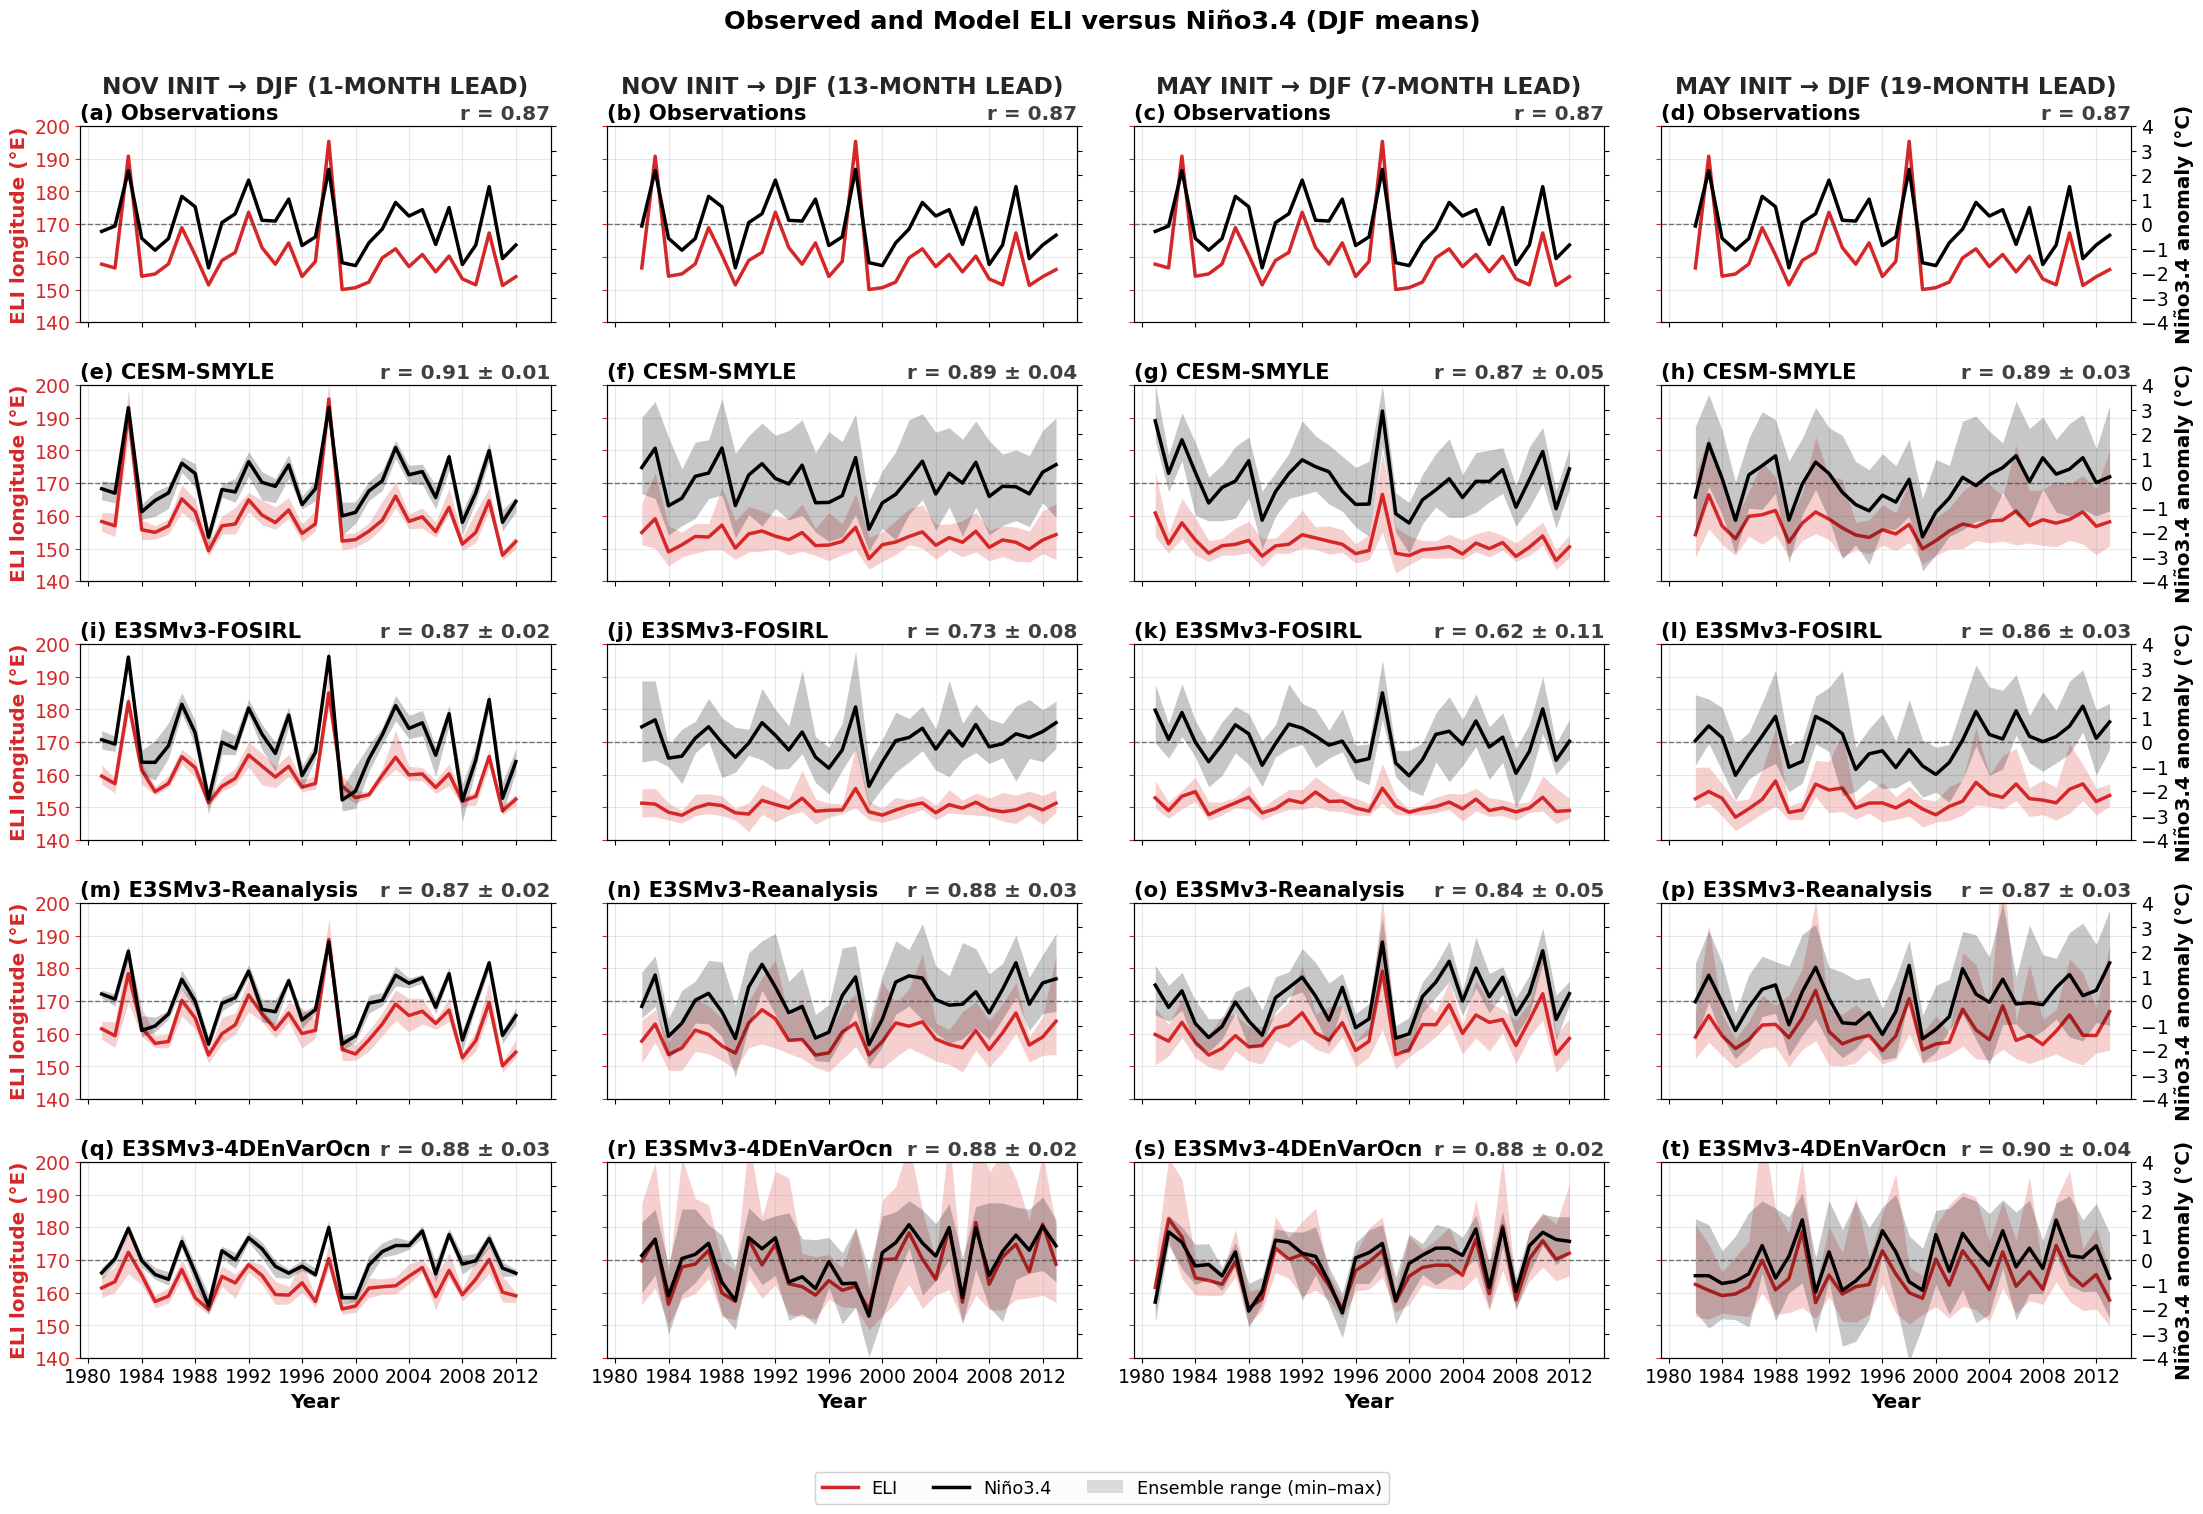

/tmp/ipykernel_815012/1641626868.py:18: UserWarning: The specified chunks separate the stored chunks along dimension "L" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  return workflow_resources.track(xr.open_dataset(path, chunks=chunks))
/tmp/ipykernel_815012/1641626868.py:18: UserWarning: The specified chunks separate the stored chunks along dimension "L" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  return workflow_resources.track(xr.open_dataset(path, chunks=chunks))
/tmp/ipykernel_815012/1641626868.py:18: UserWarning: The specified chunks separate the stored chunks along dimension "L" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  return workflow_resources.track(xr.open_dataset(path, chunks=chunks))
/tmp/ipykernel_815012/1641626868.py:18: UserWarning: The specified chunks separate the stored chunks along dimension "L" starting 


MAY init → JJA (1-month lead): common target years 1980-2011 (n=32)
  Observations: ELI–Niño3.4 r=0.867
  CESM-SMYLE: member-wise ELI–Niño3.4 r=0.947 ± 0.011
  E3SMv3-FOSIRL: member-wise ELI–Niño3.4 r=0.743 ± 0.036
  E3SMv3-Reanalysis: member-wise ELI–Niño3.4 r=0.798 ± 0.034
  E3SMv3-4DEnVarOcn: member-wise ELI–Niño3.4 r=0.766 ± 0.028

MAY init → JJA (13-month lead): common target years 1981-2012 (n=32)
  Observations: ELI–Niño3.4 r=0.866
  CESM-SMYLE: member-wise ELI–Niño3.4 r=0.896 ± 0.034
  E3SMv3-FOSIRL: member-wise ELI–Niño3.4 r=0.792 ± 0.091
  E3SMv3-Reanalysis: member-wise ELI–Niño3.4 r=0.875 ± 0.050
  E3SMv3-4DEnVarOcn: member-wise ELI–Niño3.4 r=0.789 ± 0.080

NOV init → JJA (7-month lead): common target years 1981-2012 (n=32)
  Observations: ELI–Niño3.4 r=0.866
  CESM-SMYLE: member-wise ELI–Niño3.4 r=0.848 ± 0.047
  E3SMv3-FOSIRL: member-wise ELI–Niño3.4 r=0.318 ± 0.117
  E3SMv3-Reanalysis: member-wise ELI–Niño3.4 r=0.835 ± 0.045
  E3SMv3-4DEnVarOcn: member-wise ELI–Niño3.4 r

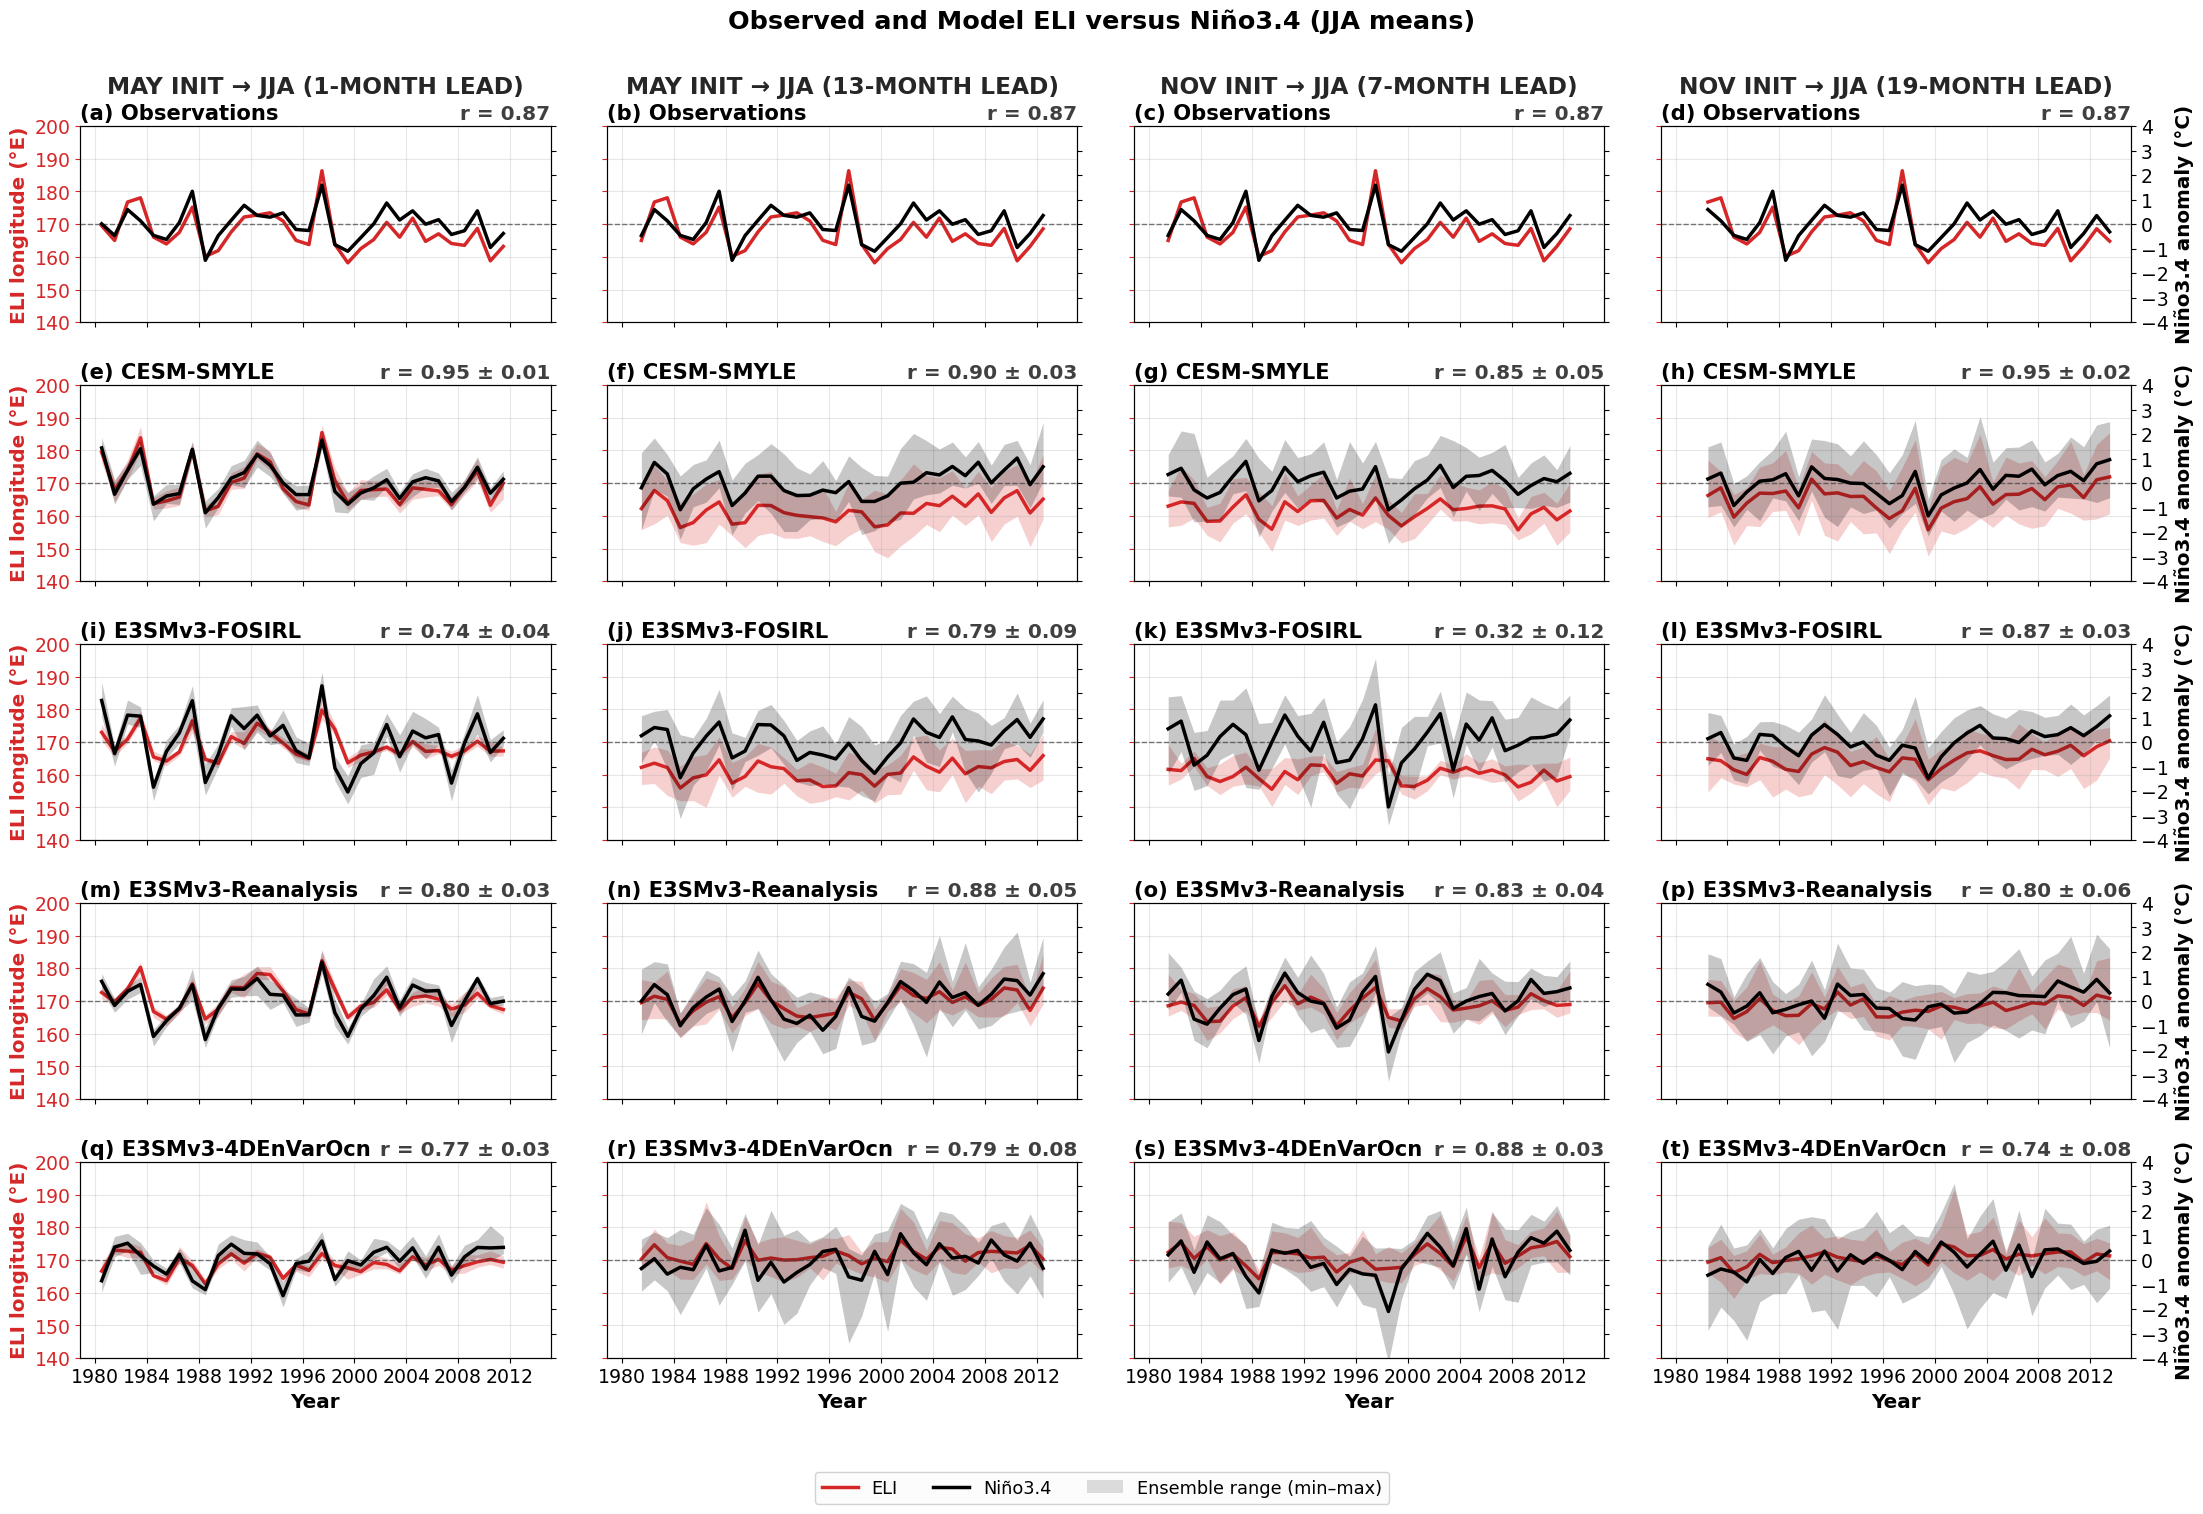

In [71]:
# -----------------------------
# Observed and model ELI–Niño3.4 dual-axis comparison
# -----------------------------
def plot_eli_nino34_comparison(plot_cfg):
    # This monthly observational series is small. Keep it NumPy-backed so
    # the centered 3-month mean cannot inherit undersized Dask edge chunks.
    nino34_raw = open_tracked_dataset(NINO34_OBS_FILE, chunks=None)["sst"].load()
    nino34_clim_mask = (
        (nino34_raw.time.dt.year >= CLIM_Y0)
        & (nino34_raw.time.dt.year <= CLIM_Y1)
    )
    nino34_clim = nino34_raw.isel(time=nino34_clim_mask).groupby("time.month").mean()
    nino34_anom = nino34_raw.groupby("time.month") - nino34_clim
    # Normalize mid-month cftime coordinates to month-start timestamps so the
    # HadISST2 series aligns exactly with the ERSSTv5 ELI timestamps.
    nino34_anom = nino34_anom.assign_coords(
        time=pd.DatetimeIndex([
            pd.Timestamp(year=int(value.year), month=int(value.month), day=1)
            for value in nino34_anom.time.values
        ])
    )

    comparison_period = slice(str(START_YEAR), str(END_YEAR + 2))
    window = int(plot_cfg["season_window"])
    eli_compare = (
        eli_obs.sel(time=comparison_period)
        .rolling(time=window, center=True, min_periods=window)
        .mean()
    )
    nino34_compare = (
        nino34_anom.sel(time=comparison_period)
        .rolling(time=window, center=True, min_periods=window)
        .mean()
    )
    eli_compare, nino34_compare = xr.align(eli_compare, nino34_compare, join="inner")

    # Keep ELI as its direct longitude index. For Niño3.4, remove each
    # model's lead-dependent climatology to retain the conventional SST anomaly.
    model_nino34_anom = {model: {} for model in MODEL_SPECS}
    for model in MODEL_SPECS:
        for init_month in INIT_MONTHS:
            path = nino34_model_path(model, init_month)
            source = open_tracked_dataset(path, chunks=ELI_CHUNKS)
            values = source["sst"]
            init_years = eli_tools.initialization_years(values.Y.values)
            values = values.assign_coords(Y=init_years).sel(Y=slice(START_YEAR, END_YEAR))
            climatology = values.sel(Y=slice(CLIM_Y0, CLIM_Y1)).mean(("Y", "M"))
            model_nino34_anom[model][init_month] = values - climatology

    lead_columns = plot_cfg["lead_columns"]
    if len(lead_columns) != 4:
        raise ValueError("lead_columns must contain exactly four initialization/lead pairs.")
    if window != 3 or window % 2 != 1:
        raise ValueError(
            f"The {plot_cfg['verification_period']} comparison requires season_window=3."
        )
    season_half_window = window // 2

    reference_model = next(iter(MODEL_SPECS))
    source_labels = ["Observations"] + [spec.label for spec in MODEL_SPECS.values()]
    column_results = []
    for column in lead_columns:
        init_month = int(column["init_month"])
        lead = int(column["lead"])
        center_lead = int(column["center_lead"])
        season_leads = np.arange(
            center_lead - season_half_window,
            center_lead + season_half_window + 1,
        )
        if init_month not in INIT_MONTHS:
            raise ValueError(f"Initialization month {init_month} is not in INIT_MONTHS.")
        if season_leads.min() < 1 or season_leads.max() > NLEAD:
            raise ValueError(
                f"{plot_cfg['verification_period']} window {season_leads.tolist()} "
                f"for displayed lead {lead} "
                f"falls outside 1-{NLEAD}."
            )
        if center_lead != lead + 2:
            raise ValueError(
                f"Displayed lead {lead} must use DJF center lead {lead + 2}, "
                f"not {center_lead}."
            )

        target_time = eli_time[reference_model][init_month].sel(L=center_lead)
        target_dates = pd.DatetimeIndex([
            pd.Timestamp(year=int(value.year), month=int(value.month), day=1)
            for value in target_time.values
        ])
        target_years = target_dates.year.to_numpy(dtype=int)
        panel_series = {
            "Observations": {
                "eli": eli_tools.observations_for_times(eli_compare, target_time.values),
                "nino34": eli_tools.observations_for_times(nino34_compare, target_time.values),
                "eli_members": None,
                "nino34_members": None,
            }
        }

        for model, spec in MODEL_SPECS.items():
            model_time = eli_time[model][init_month].sel(L=center_lead)
            model_years = np.asarray(model_time.dt.year.values, dtype=int)
            model_months = np.asarray(model_time.dt.month.values, dtype=int)
            if not np.array_equal(model_years, target_years):
                raise ValueError(f"{spec.label}: target years differ at init {init_month}, lead {lead}.")
            if not np.array_equal(model_months, target_dates.month):
                raise ValueError(f"{spec.label}: target months differ at init {init_month}, lead {lead}.")
            eli_members = (
                eli_model[model][init_month]
                .sel(L=season_leads)
                .mean("L", skipna=False)
                .transpose("Y", "M")
            )
            nino34_members = (
                model_nino34_anom[model][init_month]
                .sel(L=season_leads)
                .mean("L", skipna=False)
                .transpose("Y", "M")
            )
            spread_low, spread_high = plot_cfg["ensemble_spread_percentiles"]
            panel_series[spec.label] = {
                "eli": np.asarray(eli_members.mean("M", skipna=True), dtype=float),
                "nino34": np.asarray(nino34_members.mean("M", skipna=True), dtype=float),
                "eli_lower": np.asarray(
                    eli_members.quantile(spread_low / 100, dim="M", skipna=True), dtype=float
                ),
                "eli_upper": np.asarray(
                    eli_members.quantile(spread_high / 100, dim="M", skipna=True), dtype=float
                ),
                "nino34_lower": np.asarray(
                    nino34_members.quantile(spread_low / 100, dim="M", skipna=True), dtype=float
                ),
                "nino34_upper": np.asarray(
                    nino34_members.quantile(spread_high / 100, dim="M", skipna=True), dtype=float
                ),
                "eli_members": np.asarray(eli_members, dtype=float),
                "nino34_members": np.asarray(nino34_members, dtype=float),
            }

        common_valid = np.ones(target_dates.size, dtype=bool)
        for series in panel_series.values():
            common_valid &= np.isfinite(series["eli"]) & np.isfinite(series["nino34"])
        if common_valid.sum() < 3:
            raise ValueError(
                f"Init {init_month}, lead {lead}: only {int(common_valid.sum())} "
                "common ELI–Niño3.4 target years."
            )
        correlation_stats = {}
        for label, series in panel_series.items():
            if series["eli_members"] is None:
                correlation_stats[label] = {
                    "mean": float(np.corrcoef(
                        np.asarray(series["eli"])[common_valid],
                        np.asarray(series["nino34"])[common_valid],
                    )[0, 1]),
                    "std": None,
                }
                continue
            member_correlations = []
            for member in range(series["eli_members"].shape[1]):
                member_valid = (
                    common_valid
                    & np.isfinite(series["eli_members"][:, member])
                    & np.isfinite(series["nino34_members"][:, member])
                )
                if member_valid.sum() >= 3:
                    member_correlations.append(float(np.corrcoef(
                        series["eli_members"][member_valid, member],
                        series["nino34_members"][member_valid, member],
                    )[0, 1]))
            correlation_stats[label] = {
                "mean": float(np.nanmean(member_correlations)),
                "std": float(np.nanstd(member_correlations, ddof=1)),
            }
        column_results.append({
            "config": column,
            "dates": target_dates[common_valid],
            "years": target_years[common_valid],
            "valid": common_valid,
            "series": panel_series,
            "correlation_stats": correlation_stats,
        })

    target_months = {result["dates"][0].month for result in column_results}
    if len(target_months) != 1:
        raise ValueError(f"Lead columns do not share one target month: {sorted(target_months)}")
    if target_months != {int(plot_cfg['center_month'])}:
        raise ValueError(
            f"Expected month {int(plot_cfg['center_month']):02d}-centered "
            f"{plot_cfg['verification_period']} means, found target months "
            f"{sorted(target_months)}."
        )

    fontz = plot_cfg["font_size"]
    figure_title_fontz = fontz * plot_cfg["figure_title_font_scale"]
    column_header_fontz = fontz * plot_cfg["column_header_font_scale"]
    panel_title_fontz = fontz * plot_cfg["panel_title_font_scale"]
    axis_label_fontz = fontz * plot_cfg["axis_label_font_scale"]
    tick_fontz = fontz * plot_cfg["tick_font_scale"]
    legend_fontz = fontz * plot_cfg["legend_font_scale"]
    plt.rcParams.update({
        "font.size": fontz,
        "axes.titlesize": panel_title_fontz,
        "axes.labelsize": axis_label_fontz,
        "xtick.labelsize": tick_fontz,
        "ytick.labelsize": tick_fontz,
        "legend.fontsize": legend_fontz,
    })
    nrows, ncols = len(source_labels), len(column_results)
    fig, axes = plt.subplots(
        nrows, ncols, figsize=plot_cfg["figsize"], sharex=True, sharey=True, squeeze=False
    )
    for col, result in enumerate(column_results):
        valid = result["valid"]
        dates = result["dates"]
        for row, source_label in enumerate(source_labels):
            ax_eli = axes[row, col]
            ax_nino34 = ax_eli.twinx()
            series = result["series"][source_label]
            eli_values = np.asarray(series["eli"])[valid]
            nino34_values = np.asarray(series["nino34"])[valid]

            if series.get("eli_lower") is not None:
                ax_eli.fill_between(
                    dates, np.asarray(series["eli_lower"])[valid],
                    np.asarray(series["eli_upper"])[valid],
                    color=plot_cfg["eli_color"],
                    alpha=plot_cfg["ensemble_spread_alpha"], linewidth=0,
                )
                ax_nino34.fill_between(
                    dates, np.asarray(series["nino34_lower"])[valid],
                    np.asarray(series["nino34_upper"])[valid],
                    color=plot_cfg["nino34_color"],
                    alpha=plot_cfg["ensemble_spread_alpha"], linewidth=0,
                )

            line_eli, = ax_eli.plot(
                dates, eli_values, color=plot_cfg["eli_color"],
                linewidth=plot_cfg["line_width"], label=plot_cfg["eli_label"], zorder=4,
            )
            line_nino34, = ax_nino34.plot(
                dates, nino34_values, color=plot_cfg["nino34_color"],
                linewidth=plot_cfg["line_width"], label=plot_cfg["nino34_label"], zorder=4,
            )
            ax_eli.set_ylim(plot_cfg["eli_ylim"])
            ax_eli.set_yticks(plot_cfg["eli_yticks"])
            ax_nino34.set_ylim(plot_cfg["nino34_ylim"])
            ax_nino34.set_yticks(plot_cfg["nino34_yticks"])
            ax_eli.tick_params(
                axis="y", colors=plot_cfg["eli_color"],
                labelleft=(col == 0), labelsize=tick_fontz,
            )
            ax_nino34.tick_params(
                axis="y", colors=plot_cfg["nino34_color"],
                labelright=(col == ncols - 1), labelsize=tick_fontz,
            )
            ax_eli.tick_params(axis="x", labelsize=tick_fontz)
            if col == 0:
                ax_eli.set_ylabel(
                    plot_cfg["eli_axis_label"], color=plot_cfg["eli_color"],
                    fontsize=axis_label_fontz, fontweight="bold",
                )
            if col == ncols - 1:
                ax_nino34.set_ylabel(
                    plot_cfg["nino34_axis_label"], color=plot_cfg["nino34_color"],
                    fontsize=axis_label_fontz, fontweight="bold",
                )
            ax_nino34.axhline(
                0, color=plot_cfg["zero_line_color"],
                linewidth=plot_cfg["zero_line_width"], linestyle="--", alpha=0.7,
            )
            ax_eli.grid(True, alpha=plot_cfg["grid_alpha"])

            panel_index = row * ncols + col
            stats = result["correlation_stats"][source_label]
            r_str = f"r = {stats['mean']:.2f}"
            if stats["std"] is not None:
                r_str += f" ± {stats['std']:.2f}"

            ax_eli.set_title(
                f"({chr(97 + panel_index)}) {source_label}",
                loc="left", fontsize=panel_title_fontz, fontweight="bold", pad=5,
            )
            ax_eli.set_title(
                r_str,
                loc="right", fontsize=panel_title_fontz * 0.95, color="0.25", pad=5,
            )

            if row == nrows - 1:
                ax_eli.set_xlabel(
                    plot_cfg["target_year_label"], fontsize=axis_label_fontz, fontweight="bold",
                )

    fig.tight_layout(
        rect=plot_cfg["layout_rect"],
        h_pad=plot_cfg["layout_h_pad"],
        w_pad=plot_cfg["layout_w_pad"],
    )
    fig.subplots_adjust(
        hspace=plot_cfg["panel_hspace"], wspace=plot_cfg["panel_wspace"]
    )

    for col, result in enumerate(column_results):
        top_ax = axes[0, col]
        pos = top_ax.get_position()
        center_x = (pos.x0 + pos.x1) / 2
        header_y = pos.y1 + 0.018
        fig.text(
            center_x, header_y,
            result["config"]["label"].upper(),
            ha="center", va="bottom",
            fontsize=column_header_fontz, fontweight="bold",
            color="0.15",
        )

    fig.suptitle(
        plot_cfg["figure_title_template"].format(
            verification_period=plot_cfg["verification_period"]
        ),
        fontsize=figure_title_fontz, fontweight="bold",
        y=plot_cfg["figure_title_y"],
    )

    legend_handles = [
        line_eli,
        line_nino34,
        Patch(
            facecolor="0.6",
            alpha=plot_cfg["ensemble_spread_alpha"] * 1.5,
            edgecolor="none",
            label="Ensemble range (min–max)",
        ),
    ]
    legend_labels = [plot_cfg["eli_label"], plot_cfg["nino34_label"], "Ensemble range (min–max)"]

    fig.legend(
        handles=legend_handles,
        labels=legend_labels,
        loc=plot_cfg["legend_loc"],
        ncol=plot_cfg["legend_ncol"],
        bbox_to_anchor=plot_cfg["legend_bbox"],
        fontsize=legend_fontz,
        frameon=True,
        facecolor=plot_cfg["legend_facecolor"],
        edgecolor=plot_cfg["legend_edgecolor"],
        framealpha=plot_cfg["legend_frame_alpha"],
    )
    figpath = FIGURE_OUTDIR / figure_filename(
        *plot_cfg["filename_parts"],
        f"{plot_cfg['verification_period'].lower()}_four_init_leads",
        ext=plot_cfg["figfmt"],
    )
    column_description = "; ".join(
        f"init {int(result['config']['init_month']):02d}, DJF start lead "
        f"{int(result['config']['lead'])} (center L={int(result['config']['center_lead'])})"
        for result in column_results
    )
    mov.save_figure(
        fig, figpath, mode="", metric=plot_cfg["metric"],
        title=plot_cfg["title"],
        caption=plot_cfg["caption_template"].format(
            verification_period=plot_cfg["verification_period"],
            column_description=column_description,
        ),
        dpi=plot_cfg["dpi"],
    )
    for result in column_results:
        cfg = result["config"]
        print(f"\n{cfg['label']}: common target years {result['years'].min()}-"
              f"{result['years'].max()} (n={result['years'].size})")
        for source_label, stats in result["correlation_stats"].items():
            if stats["std"] is None:
                print(f"  {source_label}: ELI–Niño3.4 r={stats['mean']:.3f}")
            else:
                print(
                    f"  {source_label}: member-wise ELI–Niño3.4 "
                    f"r={stats['mean']:.3f} ± {stats['std']:.3f}"
                )
    print("Saved figure:", figpath)
    plt.show()


for active_plot_cfg in ELI_NINO34_PLOT_CONFIGS:
    plot_eli_nino34_comparison(active_plot_cfg)


## 4. Lead-dependent drift diagnostic

Compare each forecast system's lead climatology with the ERSSTv5 monthly climatology sampled at each verification month.


In [72]:
eli_dd, eli_drift = eli_tools.remove_lead_drift(
    eli_model,
    clim_start=CLIM_Y0,
    clim_end=CLIM_Y1,
)

for model, spec in MODEL_SPECS.items():
    for month in INIT_MONTHS:
        drift = eli_drift[model][month]
        print(
            f"{spec.label}, init {month:02d}: drift "
            f"{float(drift.min()):.2f}-{float(drift.max()):.2f} degE"
        )


CESM-SMYLE, init 05: drift 149.90-172.16 degE
CESM-SMYLE, init 11: drift 151.59-167.57 degE
E3SMv3-FOSIRL, init 05: drift 144.91-169.32 degE
E3SMv3-FOSIRL, init 11: drift 146.36-170.32 degE
E3SMv3-Reanalysis, init 05: drift 152.23-172.06 degE
E3SMv3-Reanalysis, init 11: drift 151.58-171.59 degE
E3SMv3-4DEnVarOcn, init 05: drift 153.75-174.58 degE
E3SMv3-4DEnVarOcn, init 11: drift 156.11-175.12 degE


/tmp/ipykernel_815012/1641626868.py:18: UserWarning: The specified chunks separate the stored chunks along dimension "L" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  return workflow_resources.track(xr.open_dataset(path, chunks=chunks))
/tmp/ipykernel_815012/1641626868.py:18: UserWarning: The specified chunks separate the stored chunks along dimension "L" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  return workflow_resources.track(xr.open_dataset(path, chunks=chunks))
/tmp/ipykernel_815012/1641626868.py:18: UserWarning: The specified chunks separate the stored chunks along dimension "L" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  return workflow_resources.track(xr.open_dataset(path, chunks=chunks))
/tmp/ipykernel_815012/1641626868.py:18: UserWarning: The specified chunks separate the stored chunks along dimension "L" starting 

Saved figure: /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_eli_nino34_multimodel_drift_climatology.png


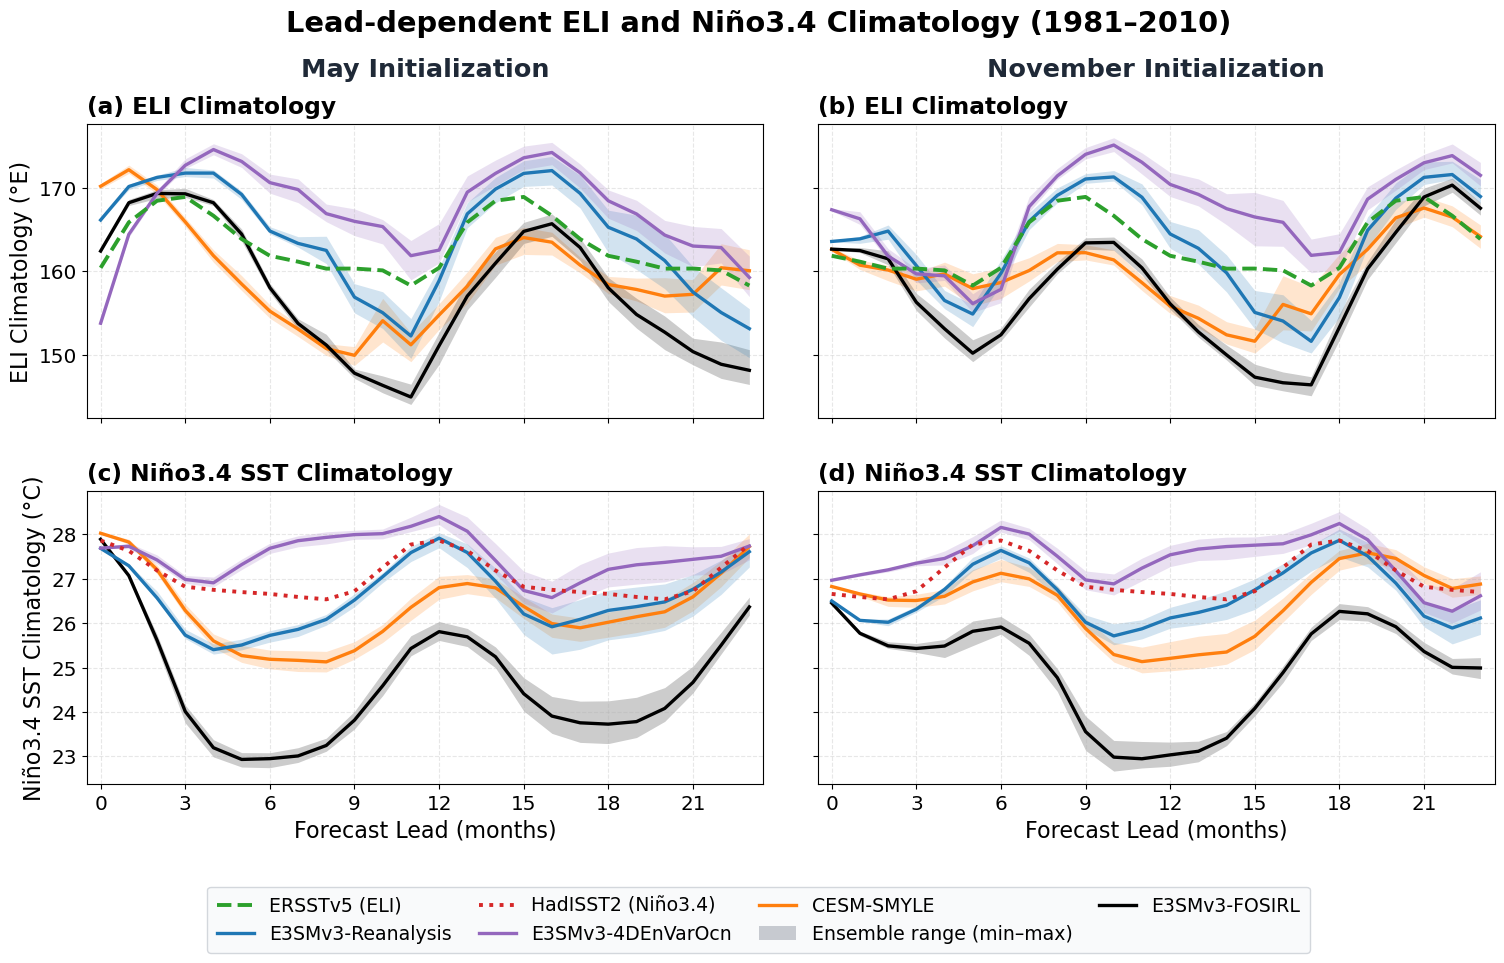

In [73]:
plot_cfg = DRIFT_CLIMATOLOGY_PLOT_CONFIG
fontz = plot_cfg["font_size"]
figure_title_fontz = fontz * plot_cfg["figure_title_font_scale"]
panel_title_fontz = fontz * plot_cfg["panel_title_font_scale"]
axis_label_fontz = fontz * plot_cfg["axis_label_font_scale"]
tick_fontz = fontz * plot_cfg["tick_font_scale"]
legend_fontz = fontz * plot_cfg["legend_font_scale"]
spread_low, spread_high = plot_cfg["ensemble_spread_percentiles"]

# Observed raw Niño3.4 SST calendar-month climatology.
nino34_obs_raw = open_tracked_dataset(NINO34_OBS_FILE)["sst"]
nino34_obs_clim_mask = (
    (nino34_obs_raw.time.dt.year >= CLIM_Y0)
    & (nino34_obs_raw.time.dt.year <= CLIM_Y1)
)
nino34_obs_clim = (
    nino34_obs_raw.isel(time=nino34_obs_clim_mask)
    .groupby("time.month")
    .mean("time", skipna=True)
)

# Member-specific 1981–2010 lead climatologies; the line is their mean
# and the shading spans their configured percentile range.
eli_member_clim = {model: {} for model in MODEL_SPECS}
nino34_member_clim = {model: {} for model in MODEL_SPECS}
for model, spec in MODEL_SPECS.items():
    for month in INIT_MONTHS:
        eli_member_clim[model][month] = (
            eli_model[model][month]
            .sel(Y=slice(CLIM_Y0, CLIM_Y1))
            .mean("Y", skipna=True)
        )
        source = open_tracked_dataset(
            nino34_model_path(model, month), chunks=ELI_CHUNKS
        )
        nino34_values = source["sst"]
        nino34_init_years = eli_tools.initialization_years(nino34_values.Y.values)
        nino34_values = nino34_values.assign_coords(Y=nino34_init_years)
        nino34_member_clim[model][month] = (
            nino34_values
            .sel(Y=slice(CLIM_Y0, CLIM_Y1))
            .mean("Y", skipna=True)
        )

diagnostic_rows = [
    {
        "name": "ELI", "title": "ELI Climatology", "obs": obs_clim, "models": eli_member_clim,
        "obs_label": plot_cfg["eli_obs_label"],
        "obs_color": plot_cfg["eli_obs_color"],
        "obs_linestyle": plot_cfg["eli_obs_linestyle"],
        "ylabel": plot_cfg["eli_ylabel"],
    },
    {
        "name": "Niño3.4", "title": "Niño3.4 SST Climatology", "obs": nino34_obs_clim,
        "models": nino34_member_clim,
        "obs_label": plot_cfg["nino34_obs_label"],
        "obs_color": plot_cfg["nino34_obs_color"],
        "obs_linestyle": plot_cfg["nino34_obs_linestyle"],
        "ylabel": plot_cfg["nino34_ylabel"],
    },
]

plt.rcParams.update({
    "font.size": fontz,
    "axes.titlesize": panel_title_fontz,
    "axes.titleweight": "bold",
    "axes.labelsize": axis_label_fontz,
    "xtick.labelsize": tick_fontz,
    "ytick.labelsize": tick_fontz,
})
fig, axes = plt.subplots(
    len(diagnostic_rows), len(INIT_MONTHS),
    figsize=plot_cfg["figsize"], sharex=True, sharey="row", squeeze=False,
)

fig.subplots_adjust(**plot_cfg["subplot_adjust"])

fig.suptitle(
    plot_cfg["figure_title"], fontsize=figure_title_fontz,
    fontweight="bold", y=plot_cfg["figure_title_y"],
)

panel_letters = [["a", "b"], ["c", "d"]]

for col, month in enumerate(INIT_MONTHS):
    reference_times = eli_time[next(iter(MODEL_SPECS))][month].isel(Y=0)
    target_months = np.asarray(reference_times.dt.month.values, dtype=int)
    leads = np.asarray(reference_times.L.values, dtype=int)
    lead_axis = leads - 1

    top_ax = axes[0, col]
    bbox = top_ax.get_position()
    col_center_x = (bbox.x0 + bbox.x1) / 2.0
    fig.text(
        col_center_x, 0.905,
        plot_cfg["init_labels"][month],
        ha="center", va="center",
        fontsize=fontz * 1.15,
        fontweight="bold",
        color="#1f2937",
    )
    for row, diagnostic in enumerate(diagnostic_rows):
        ax = axes[row, col]
        obs_target_clim = np.asarray([
            float(diagnostic["obs"].sel(month=target_month))
            for target_month in target_months
        ])
        ax.plot(
            lead_axis, obs_target_clim, color=diagnostic["obs_color"],
            linewidth=plot_cfg["obs_line_width"],
            linestyle=diagnostic["obs_linestyle"],
            zorder=4,
        )

        for model, spec in MODEL_SPECS.items():
            member_clim = diagnostic["models"][model][month].sel(L=leads)
            model_mean = member_clim.mean("M", skipna=True)
            model_lower = member_clim.quantile(spread_low / 100, dim="M", skipna=True)
            model_upper = member_clim.quantile(spread_high / 100, dim="M", skipna=True)
            ax.fill_between(
                lead_axis, model_lower, model_upper, color=spec.color,
                alpha=plot_cfg["ensemble_spread_alpha"], linewidth=0, zorder=1,
            )
            ax.plot(
                lead_axis, model_mean, color=spec.color,
                linewidth=plot_cfg["model_line_width"],
                zorder=3,
            )

        letter = panel_letters[row][col]
        ax.set_title(
            f"({letter}) {diagnostic['title']}",
            loc="left", pad=8,
        )
        if col == 0:
            ax.set_ylabel(diagnostic["ylabel"], fontsize=axis_label_fontz)
        else:
            ax.tick_params(labelleft=False)

        if row == len(diagnostic_rows) - 1:
            ax.set_xlabel(plot_cfg["xlabel"], fontsize=axis_label_fontz)

        ax.grid(True, linestyle="--", alpha=plot_cfg["grid_alpha"])
        ax.xaxis.set_major_locator(
            mticker.MultipleLocator(plot_cfg["lead_tick_interval"])
        )
        ax.set_xlim(-0.5, 23.5)

legend_elements = [
    Line2D([0], [0], color=plot_cfg["eli_obs_color"], lw=2.8, linestyle=plot_cfg["eli_obs_linestyle"], label=plot_cfg["eli_obs_label"]),
    Line2D([0], [0], color=plot_cfg["nino34_obs_color"], lw=2.8, linestyle=plot_cfg["nino34_obs_linestyle"], label=plot_cfg["nino34_obs_label"]),
]
for model, spec in MODEL_SPECS.items():
    legend_elements.append(
        Line2D([0], [0], color=spec.color, lw=2.4, label=spec.label)
    )
legend_elements.append(
    Patch(facecolor="#6b7280", edgecolor="none", alpha=0.35, label="Ensemble range (min–max)")
)

# Matplotlib fills multi-row legends column-first; reorder the handles so
# the visible legend reads left-to-right across each row.
legend_ncol = plot_cfg["legend_ncol"]
legend_nrow = (len(legend_elements) + legend_ncol - 1) // legend_ncol
legend_grid = [
    legend_elements[row * legend_ncol:(row + 1) * legend_ncol]
    for row in range(legend_nrow)
]
legend_elements = [
    legend_grid[row][col]
    for col in range(legend_ncol)
    for row in range(legend_nrow)
    if col < len(legend_grid[row])
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=plot_cfg["legend_bbox"],
    ncol=plot_cfg["legend_ncol"],
    frameon=True,
    facecolor="#f9fafb",
    edgecolor="#d1d5db",
    framealpha=0.95,
    fontsize=legend_fontz,
    columnspacing=1.4,
    handlelength=2.0,
    borderpad=0.5,
)
figpath = FIGURE_OUTDIR / figure_filename(*plot_cfg["filename_parts"])
mov.save_figure(
    fig, figpath, mode="", metric=plot_cfg["metric"],
    title=plot_cfg["figure_title"],
    caption=(
        f"Lead-dependent ELI longitude and raw Niño3.4 SST climatologies over "
        f"{CLIM_Y0}–{CLIM_Y1}. Model lines average member-specific "
        f"climatologies; light shading shows the ensemble minimum–maximum range."
    ),
    dpi=plot_cfg["dpi"],
)
print("Saved figure:", figpath)
plt.show()


## Clean up


In [74]:
close_notebook_resources(globals())
print("Closed ELI diagnostic datasets and Dask resources.")


Closed ELI diagnostic datasets and Dask resources.
